<a href="https://colab.research.google.com/github/harendradadhich/notebooks/blob/main/Retail_Sales_Prediction_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <b><u> Project Title : Sales Prediction : Predicting sales of a major store chain Rossmann</u></b>

## <b> Problem Description </b>

### Rossmann operates over 3,000 drug stores in 7 European countries. Currently, Rossmann store managers are tasked with predicting their daily sales for up to six weeks in advance. Store sales are influenced by many factors, including promotions, competition, school and state holidays, seasonality, and locality. With thousands of individual managers predicting sales based on their unique circumstances, the accuracy of results can be quite varied.

### You are provided with historical sales data for 1,115 Rossmann stores. The task is to forecast the "Sales" column for the test set. Note that some stores in the dataset were temporarily closed for refurbishment.

## <b> Data Description </b>

### <b>Rossmann Stores Data.csv </b> - historical data including Sales
### <b>store.csv </b> - supplemental information about the stores


### <b><u>Data fields</u></b>
### Most of the fields are self-explanatory. The following are descriptions for those that aren't.

* #### Id - an Id that represents a (Store, Date) duple within the test set
* #### Store - a unique Id for each store
* #### Sales - the turnover for any given day (this is what you are predicting)
* #### Customers - the number of customers on a given day
* #### Open - an indicator for whether the store was open: 0 = closed, 1 = open
* #### StateHoliday - indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays. Note that all schools are closed on public holidays and weekends. a = public holiday, b = Easter holiday, c = Christmas, 0 = None
* #### SchoolHoliday - indicates if the (Store, Date) was affected by the closure of public schools
* #### StoreType - differentiates between 4 different store models: a, b, c, d
* #### Assortment - describes an assortment level: a = basic, b = extra, c = extended
* #### CompetitionDistance - distance in meters to the nearest competitor store
* #### CompetitionOpenSince[Month/Year] - gives the approximate year and month of the time the nearest competitor was opened
* #### Promo - indicates whether a store is running a promo on that day
* #### Promo2 - Promo2 is a continuing and consecutive promotion for some stores: 0 = store is not participating, 1 = store is participating
* #### Promo2Since[Year/Week] - describes the year and calendar week when the store started participating in Promo2
* #### PromoInterval - describes the consecutive intervals Promo2 is started, naming the months the promotion is started anew. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that store

## Loading Libraries & Data

In [5]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import missingno as msno
import matplotlib
import matplotlib.pylab as pylab

%matplotlib inline
matplotlib.style.use('ggplot')
sns.set_style('white')
pylab.rcParams['figure.figsize'] = 8,6

import math
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from math import sqrt

import lightgbm as lgb
import xgboost as xgb

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.linear_model import LassoLars
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import ElasticNet
# Statistical Analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import ttest_ind
import statsmodels.api as sm

# import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
import xgboost as xgb
from time import time
import os
# statistics
from statsmodels.distributions.empirical_distribution import ECDF
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
import warnings
import itertools
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf,pacf
from statsmodels.tsa.arima_model import  ARIMA
from pandas import DataFrame

In [6]:
# #mounting drive
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
#Loading Rossman Dataset
rossman_df= pd.read_csv('train.csv', low_memory= False)

In [8]:
#Loading Store Dataset
store_df=pd.read_csv('store.csv', low_memory= False)

## **Analysing the Rossman Dataset**

In [9]:
rossman_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [10]:
rossman_df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1
1017208,1115,2,2013-01-01,0,0,0,0,a,1


##### **Checking Information about Dataset**

In [11]:
rossman_df.shape

(1017209, 9)

In [12]:
#Checking info of data as data types and rows and cols
rossman_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [13]:
#Checking Null Values
rossman_df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


**Summary Statastics Of Dataset**

In [14]:
#Summary Statastics
rossman_df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [15]:
#No. Of Stores in the Dataset
rossman_df.Store.nunique()

1115

In [16]:
# Value_counts of StateHoliday Column
rossman_df.StateHoliday.value_counts()

,count
StateHoliday,
0,986159
a,20260
b,6690
c,4100


In [17]:
print(rossman_df['Date'].min(),'initial')
print(rossman_df['Date'].max(),'final')

2013-01-01 initial
2015-07-31 final


**This tells us we have a data of almost 3 years.**

In [18]:
rossman_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


### Handling Invalid Date Entries in `rossman_df['Date']`

To address the `ValueError` when converting the 'Date' column, we'll use `errors='coerce'` to turn invalid date strings into `NaT` (Not a Time). Then, we'll inspect these `NaT` values to understand their impact.

In [19]:
# Convert 'Date' column to datetime, coercing errors to NaT
rossman_df['Date'] = pd.to_datetime(rossman_df['Date'], errors='coerce')

# Check for NaT values (originally invalid dates)
invalid_dates_count = rossman_df['Date'].isnull().sum()
print(f"Number of invalid date entries (converted to NaT): {invalid_dates_count}")

# Display rows with NaT dates to inspect them
if invalid_dates_count > 0:
    print("\nRows with invalid dates:")
    display(rossman_df[rossman_df['Date'].isnull()])

# Depending on the analysis, you might want to drop these rows or fill them.
# For now, we will proceed assuming these rows might be dropped later if necessary
# or that the model can handle NaT if it's used after further preprocessing.

# You can drop them like this:
# rossman_df.dropna(subset=['Date'], inplace=True)


Number of invalid date entries (converted to NaT): 0


After handling the invalid date entries, we can now safely extract year, month, day, and week of year from the 'Date' column.

In [20]:
# extract year, month, day and week of year from "Date"

rossman_df['Year'] = rossman_df['Date'].apply(lambda x: x.year if pd.notna(x) else np.nan)
rossman_df['Month'] = rossman_df['Date'].apply(lambda x: x.month if pd.notna(x) else np.nan)
rossman_df['Day'] = rossman_df['Date'].apply(lambda x: x.day if pd.notna(x) else np.nan)
# Use isocalendar().week for WeekOfYear as .weekofyear is deprecated and might give warnings.
rossman_df['WeekOfYear'] = rossman_df['Date'].apply(lambda x: x.isocalendar().week if pd.notna(x) else np.nan)

print("Date-related features extracted successfully. Showing head of rossman_df:")
display(rossman_df.head())


Date-related features extracted successfully. Showing head of rossman_df:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31,31


In [21]:
rossman_df.sort_values(by=['Date','Store'],inplace=True,ascending=[False,True])
rossman_df.head(2)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,31


## **EDA On Rossman Dataset**

#### **Heatmap of the Rossman Dataset**

<Axes: >

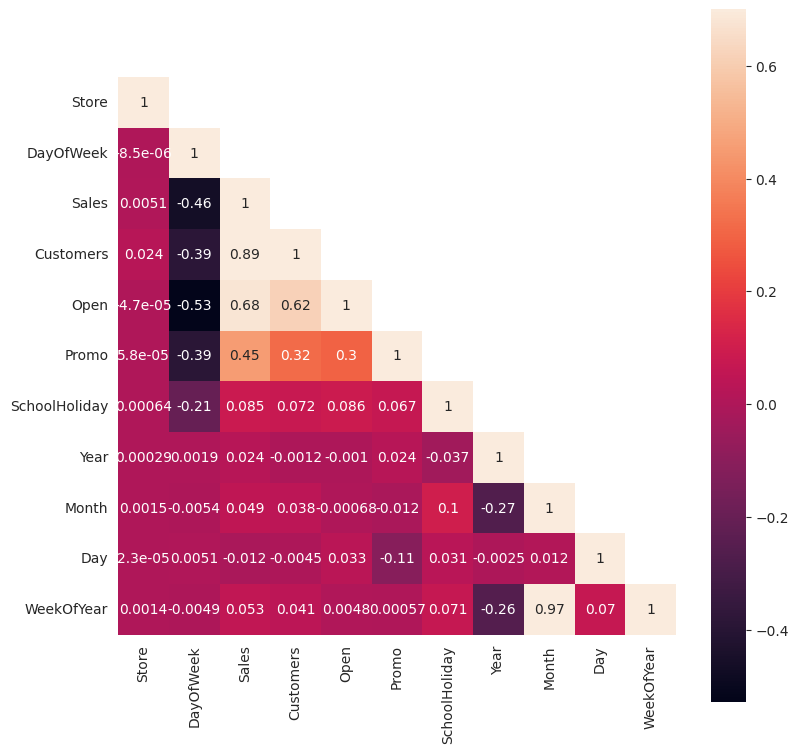

In [22]:
correlation_map = rossman_df.select_dtypes(include=np.number).corr()
obj = np.array(correlation_map)
obj[np.tril_indices_from(obj)] = False
fig,ax= plt.subplots()
fig.set_size_inches(9,9)
sns.heatmap(correlation_map, mask=obj,vmax=.7, square=True,annot=True)

**As we can see that in the graph given below that Stores mainly closed on Sunday**

<Axes: xlabel='DayOfWeek', ylabel='count'>

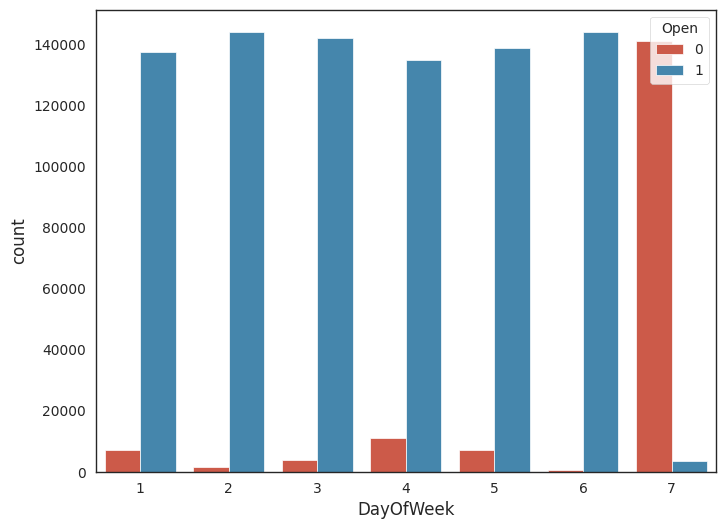

In [23]:
sns.countplot(x='DayOfWeek',hue='Open',data=rossman_df)

**Sales Are nearly doubled High When Promo is Running**

<Axes: xlabel='Promo', ylabel='Sales'>

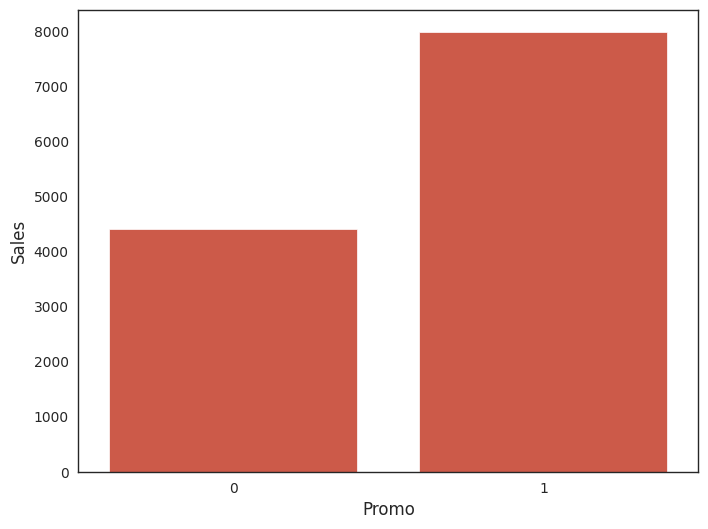

In [24]:
#Impact of promo on sales
Promo_sales = pd.DataFrame(rossman_df.groupby('Promo').agg({'Sales':'mean'}))
sns.barplot(x=Promo_sales.index, y = Promo_sales['Sales'])

In [25]:
rossman_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,2013,1,1,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1,2013,1,1,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1,2013,1,1,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1,2013,1,1,1


**As We can see that In the month of November and Specially in December Sales is increasing Rapidly every year on the christmas eve.**

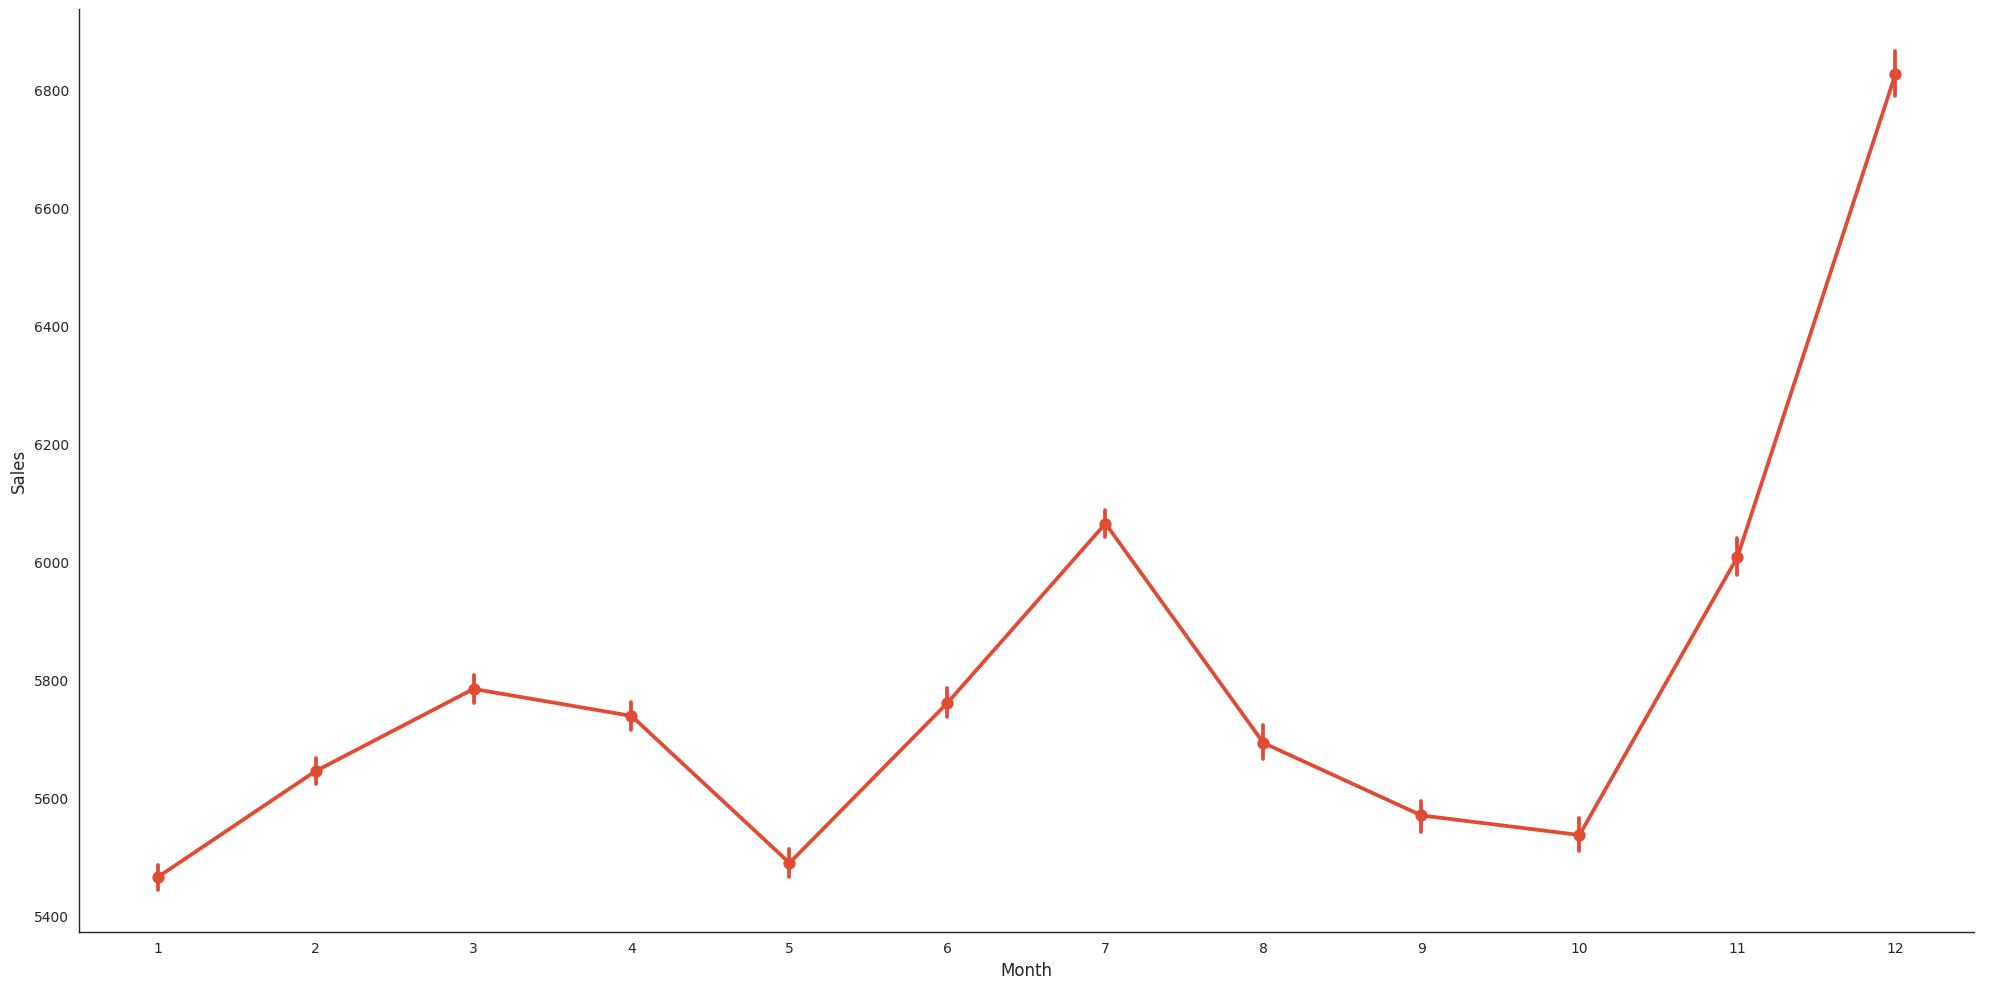

In [26]:
sns.catplot(x="Month" ,y = "Sales" , data=rossman_df, kind="point", aspect=2,height=10)

In [27]:
# Value Counts of SchoolHoliday Column
rossman_df.SchoolHoliday.value_counts()

,count
SchoolHoliday,
0,835488
1,181721


**As we can see in the Piechart Sales affected by School Holiday is 18% and Mainly Sales aren't afffected by School Holiday**

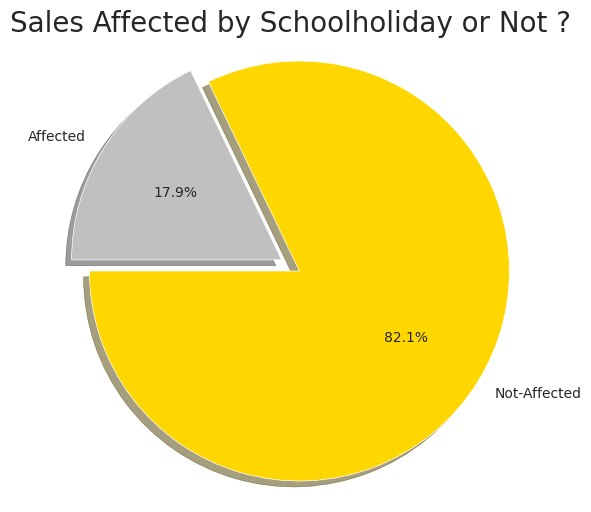

In [28]:
labels = 'Not-Affected' , 'Affected'
sizes = rossman_df.SchoolHoliday.value_counts()
colors = ['gold', 'silver']
explode = (0.1, 0.0)
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=180)
plt.axis('equal')
plt.title("Sales Affected by Schoolholiday or Not ?",fontsize=20)
plt.plot()
fig=plt.gcf()
fig.set_size_inches(6,6)
plt.show()


### **Transforming Variable StateHoliday**

In [29]:
rossman_df["StateHoliday"] = rossman_df["StateHoliday"].map({0: 0, "0": 0, "a": 1, "b": 1, "c": 1})

In [30]:
rossman_df.StateHoliday.value_counts()

,count
StateHoliday,
0,986159
1,31050


**As we can see in the Piechart Sales affected by State Holiday is only 3% means Sales aren't afffected by State Holiday**

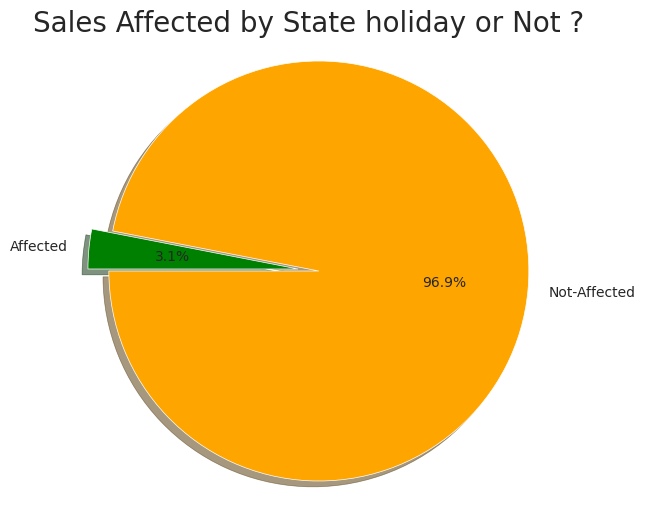

In [31]:
labels = 'Not-Affected' , 'Affected'
sizes = rossman_df.StateHoliday.value_counts()
colors = ['orange','green']
explode = (0.1, 0.0)
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=180)
plt.axis('equal')
plt.title("Sales Affected by State holiday or Not ?",fontsize=20)
plt.plot()
fig=plt.gcf()
fig.set_size_inches(6,6)
plt.show()

**As Sales isn't much affected by State Holiday so i'm removing this column**

In [32]:
rossman_df.drop('StateHoliday',inplace=True,axis=1)

**Histogram Representation of Sales. Here 0 is showing because most of the time store was closed.**

/tmp/ipython-input-2144428938.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(rossman_df['Sales'], kde = False,bins=40);


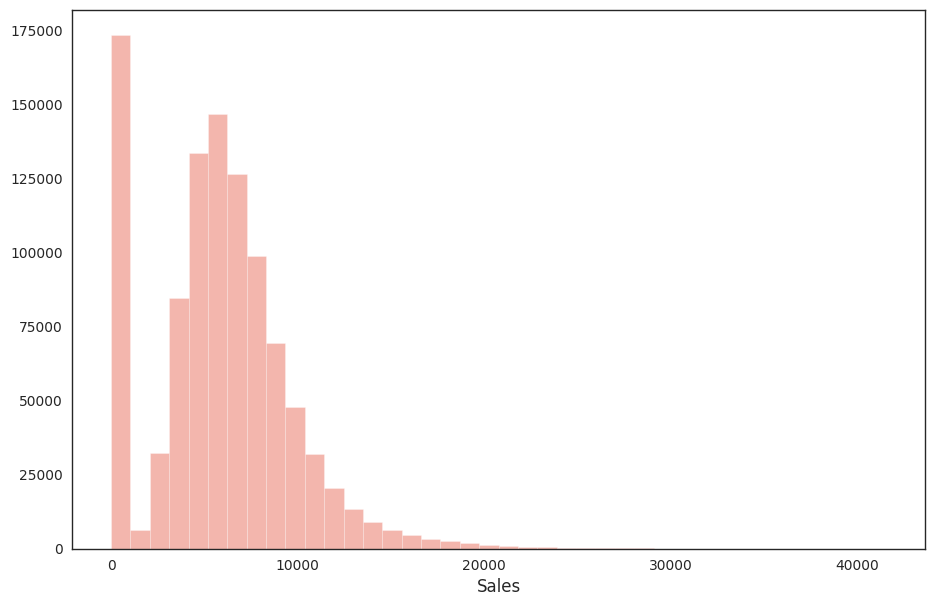

In [33]:
#distribution of sales
fig, ax = plt.subplots()
fig.set_size_inches(11, 7)
sns.distplot(rossman_df['Sales'], kde = False,bins=40);

**Sales vs Customers**

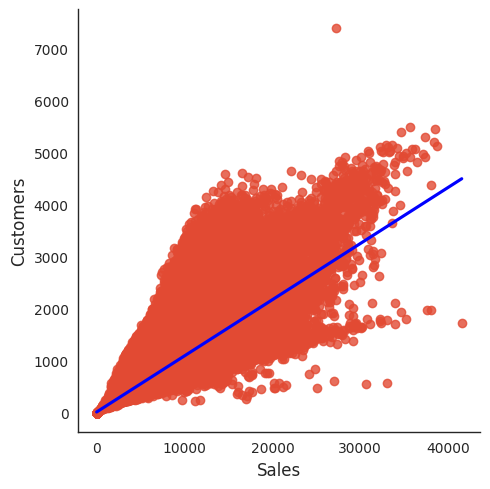

In [34]:
#linear relation between sales and customers
sns.lmplot(x= 'Sales' , y ='Customers',data=rossman_df, palette='seismic', height=5,aspect=1, line_kws={'color':'blue'});

## **Analysing the Store Dataset**

In [35]:
store_df.head(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [36]:
store_df.tail()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN
1114,1115,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"


##### **Checking Information about Dataset**

In [37]:
store_df.shape

(1115, 10)

In [38]:
#Checking info of data as data types and rows and cols
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [39]:
#Checking Null Values
store_df.isnull().sum()

,0
Store,0
StoreType,0
Assortment,0
CompetitionDistance,3
CompetitionOpenSinceMonth,354
CompetitionOpenSinceYear,354
Promo2,0
Promo2SinceWeek,544
Promo2SinceYear,544
PromoInterval,544


**Heatmap for null values**

<Axes: >

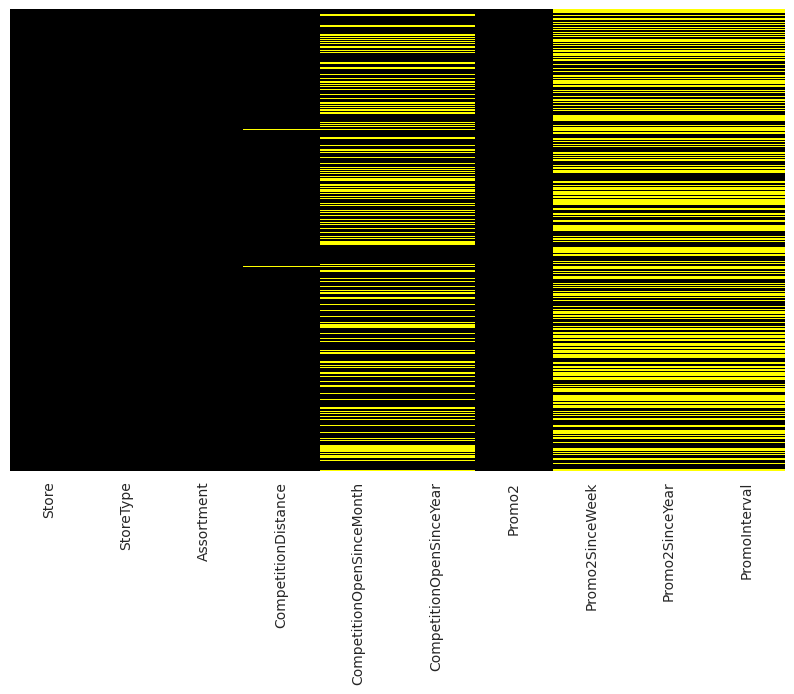

In [40]:
# creating heatmap for null values
plt.figure(figsize=(10,6))
sns.heatmap(store_df.isnull(),yticklabels= False, cbar= False, cmap= 'gnuplot')

**Distribution Of Different Store Types**

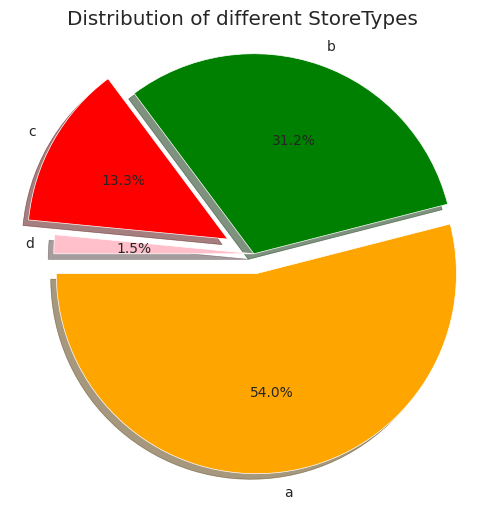

In [41]:
labels = 'a' , 'b' , 'c' , 'd'
sizes = store_df.StoreType.value_counts()
colors = ['orange', 'green' , 'red' , 'pink']
explode = (0.1, 0.0 , 0.15 , 0.0)
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=180)
plt.axis('equal')
plt.title("Distribution of different StoreTypes")
plt.plot()
fig=plt.gcf()
fig.set_size_inches(6,6)
plt.show()


#### **The distribution is right skewed, so we'll replace missing values with the median.**

In [42]:
# replace missing values in CompetitionDistance with median for the store dataset

store_df.CompetitionDistance.fillna(store_df.CompetitionDistance.median(), inplace=True)

/tmp/ipython-input-2781003425.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  store_df.CompetitionDistance.fillna(store_df.CompetitionDistance.median(), inplace=True)


**Pairplot for Store Dataset**

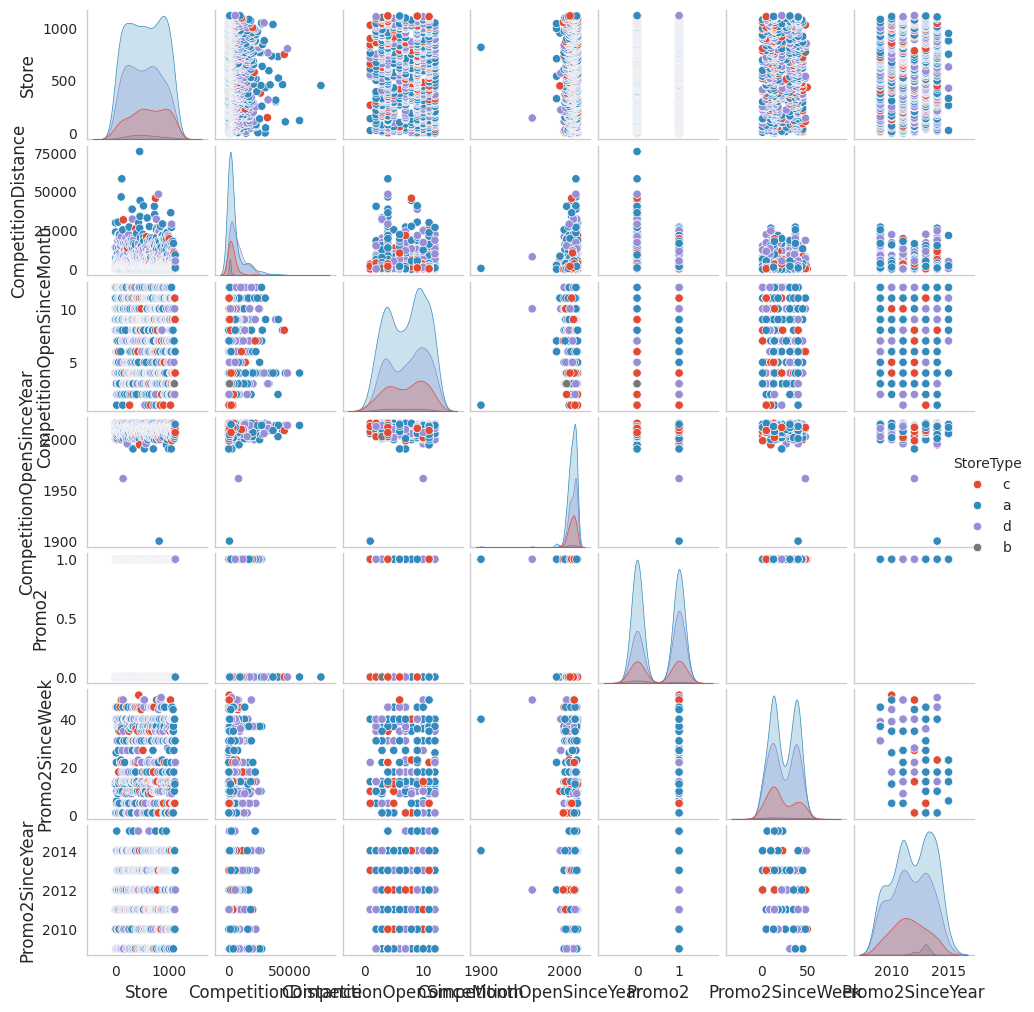

In [43]:
#pairplot for store dataset
sns.set_style("whitegrid", {'axes.grid' : False})
pp=sns.pairplot(store_df,hue='StoreType')
pp.fig.set_size_inches(10,10);

**Checking stores with their assortment type**

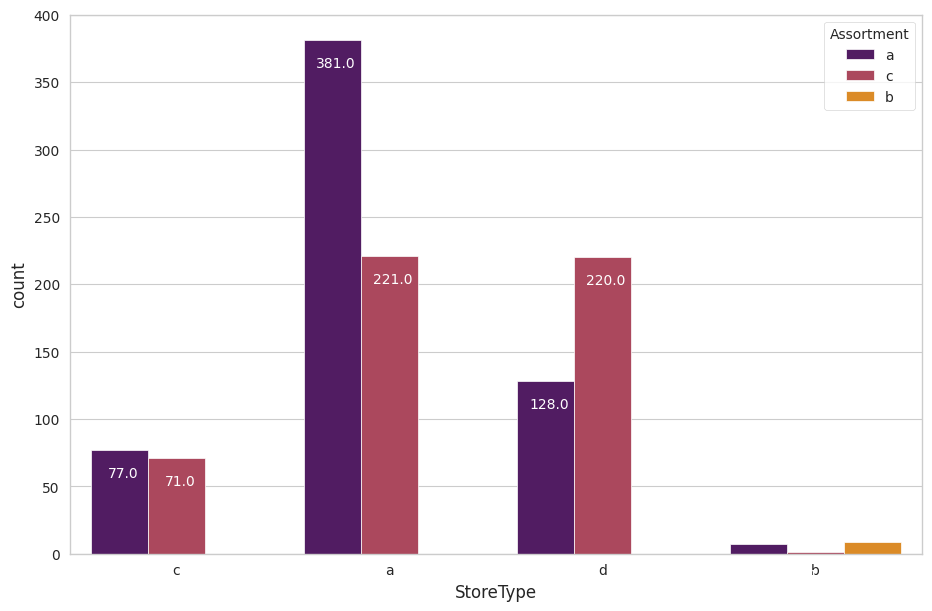

In [44]:
#checking stores with their assortment type
sns.set_style("whitegrid")
fig, ax = plt.subplots()
fig.set_size_inches(11, 7)
store_type=sns.countplot(x='StoreType',hue='Assortment', data=store_df,palette="inferno")

for p in store_type.patches:
    store_type.annotate(f'\n{p.get_height()}', (p.get_x()+0.15, p.get_height()),ha='center', va='top', color='white', size=10)

In [45]:
rossman_df.Year.value_counts()

,count
Year,
2013,406974
2014,373855
2015,236380


***We can see that there is not such significant differences in these 3 years in terms of sales.***

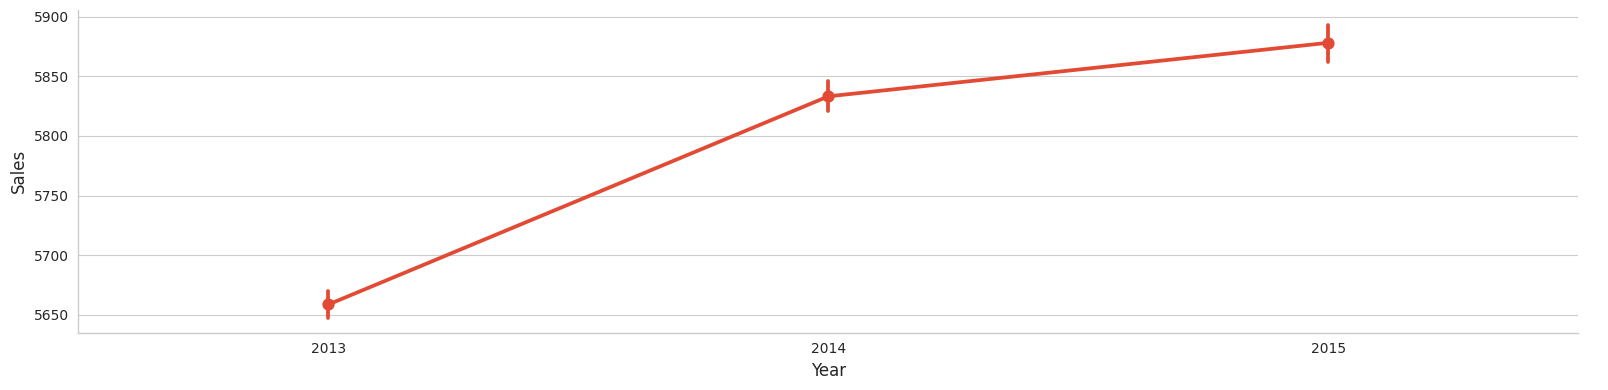

In [46]:
#plotting year vs sales
sns.catplot(x='Year',y='Sales',data=rossman_df, height=4, aspect=4 ,kind= 'point');

### **Merging Two Datasets**

In [47]:
df = pd.merge(rossman_df, store_df, how='left', on='Store')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,Year,Month,...,WeekOfYear,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,1,2015,7,...,31,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,1,2015,7,...,31,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,1,2015,7,...,31,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,1,2015,7,...,31,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,1,2015,7,...,31,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [48]:
df.shape

(1017209, 21)

## **EDA On Merged Dataset**

#### **Heatmap Of Merged Dataset**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

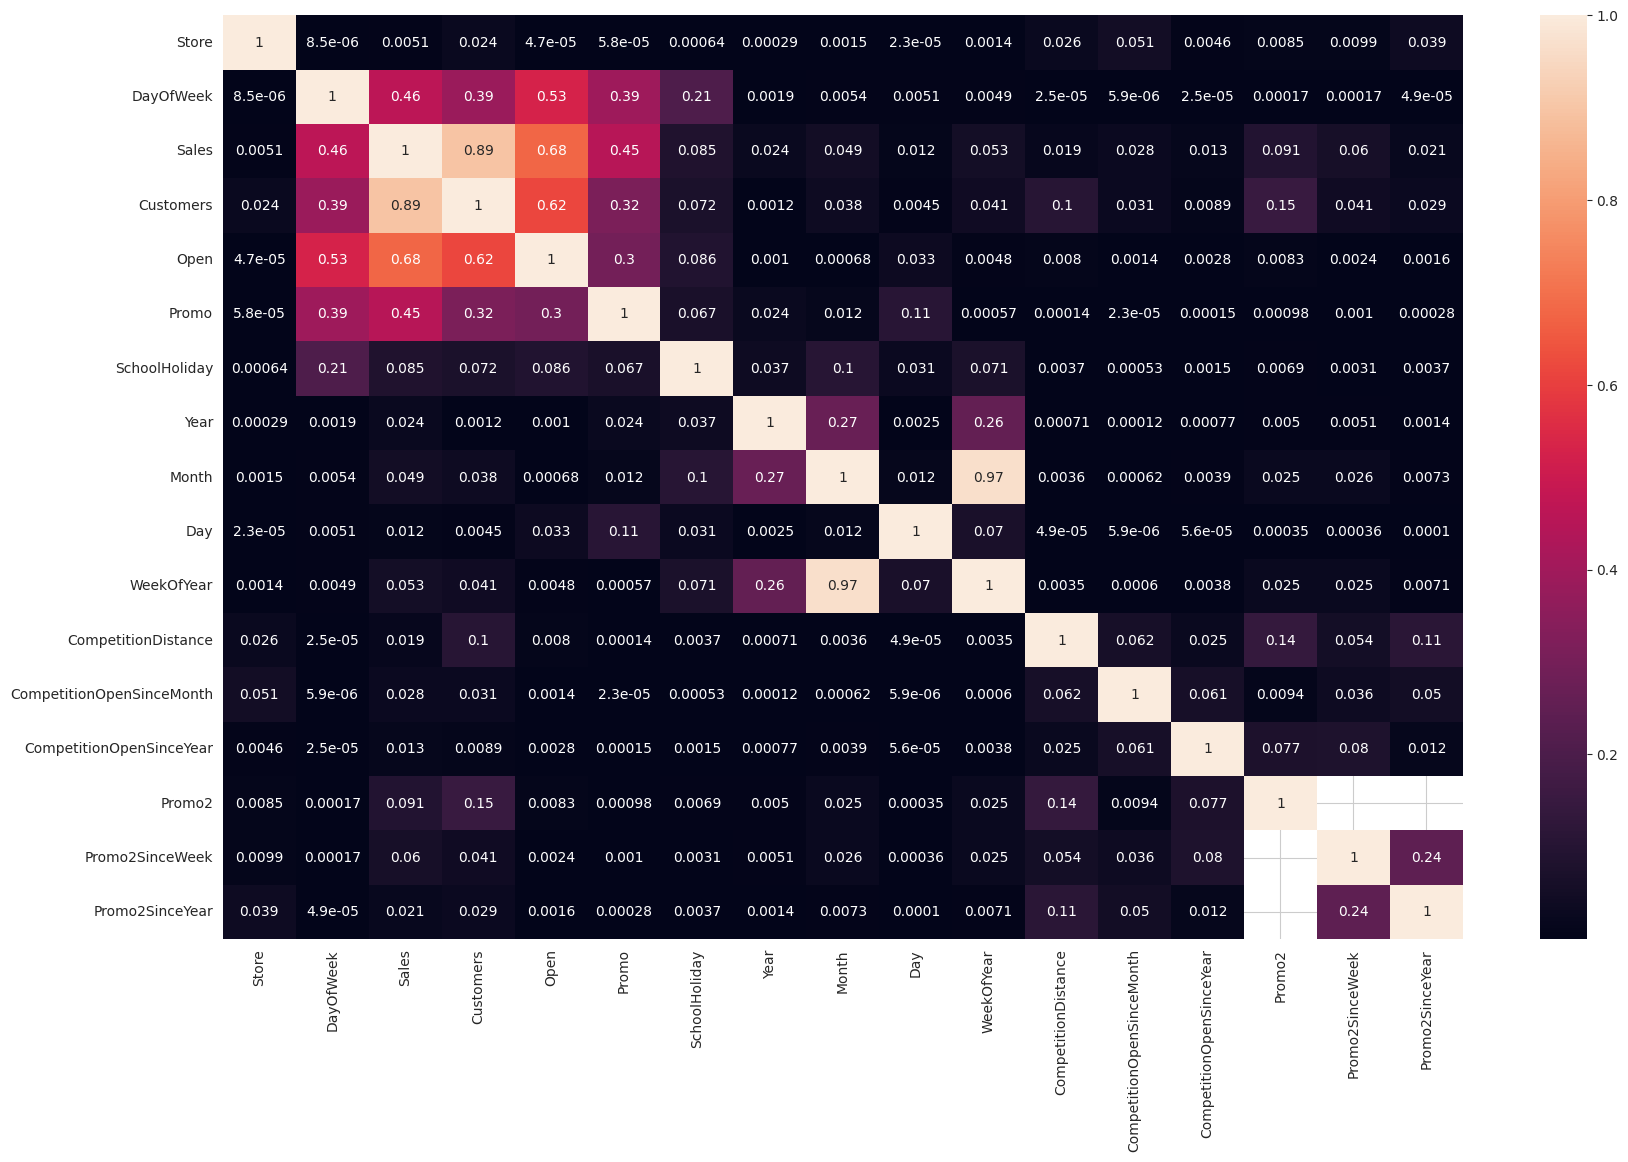

In [49]:
plt.subplots(figsize=(20,12))
sns.heatmap(df.select_dtypes(include=np.number).corr().abs(), annot=True)
plt.savefig("heatmap.png")

from google.colab import files
files.download('heatmap.png') # this line opens your documents in your pc to save your png

In [50]:
df["Avg_Customer_Sales"] = df.Sales/df.Customers

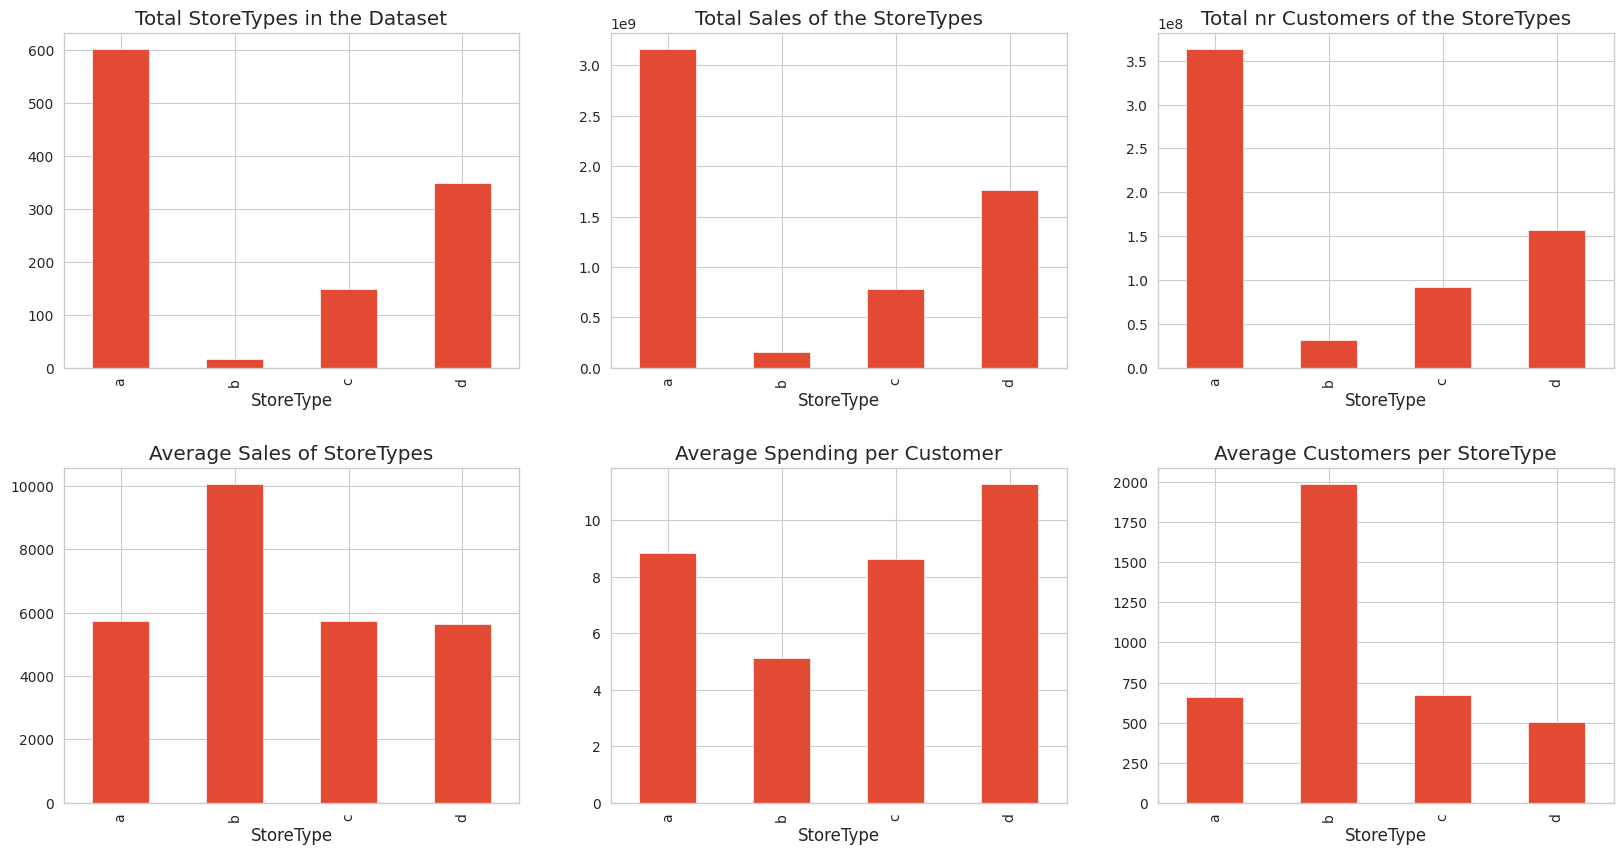

In [51]:
f, ax = plt.subplots(2, 3, figsize = (20,10))

store_df.groupby("StoreType")["Store"].count().plot(kind = "bar", ax = ax[0, 0], title = "Total StoreTypes in the Dataset")
df.groupby("StoreType")["Sales"].sum().plot(kind = "bar", ax = ax[0,1], title = "Total Sales of the StoreTypes")
df.groupby("StoreType")["Customers"].sum().plot(kind = "bar", ax = ax[0,2], title = "Total nr Customers of the StoreTypes")
df.groupby("StoreType")["Sales"].mean().plot(kind = "bar", ax = ax[1,0], title = "Average Sales of StoreTypes")
df.groupby("StoreType")["Avg_Customer_Sales"].mean().plot(kind = "bar", ax = ax[1,1], title = "Average Spending per Customer")
df.groupby("StoreType")["Customers"].mean().plot(kind = "bar", ax = ax[1,2], title = "Average Customers per StoreType")

plt.subplots_adjust(hspace = 0.3)
plt.show()

**As we can see from the graphs, the StoreType A has the most stores, sales and customers. However the StoreType D has the best averages spendings per customers. StoreType B, with only 17 stores has the most average customers.**

#### **Lets go ahead with the promotions**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

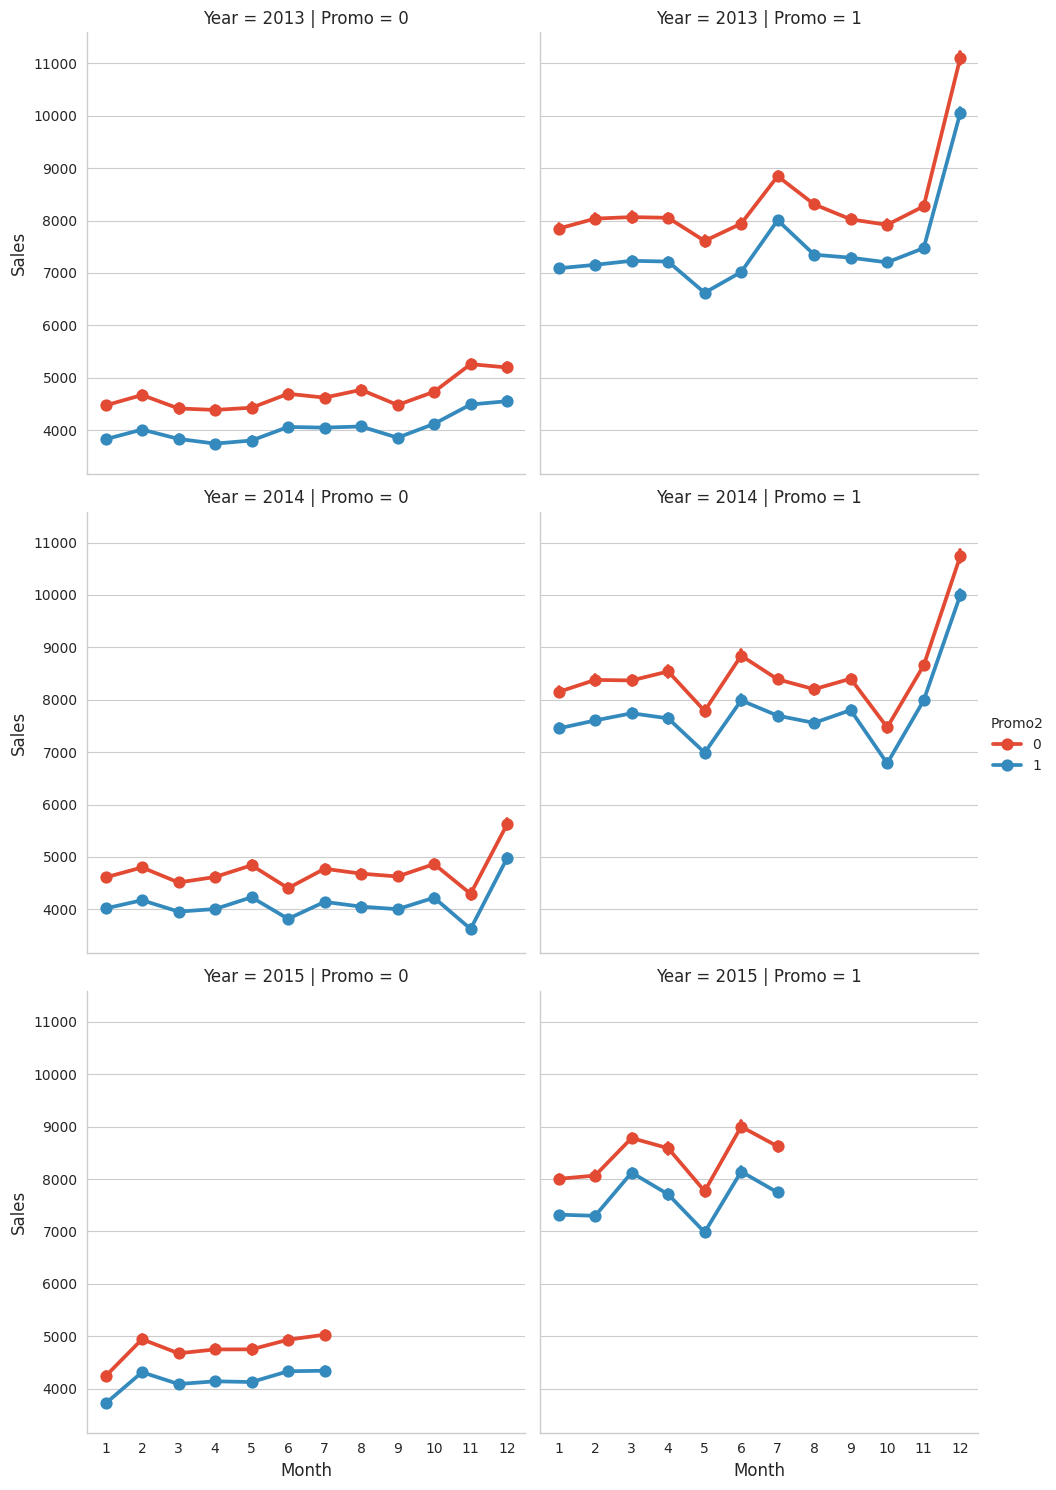

In [52]:
sns.catplot(data = df, x ="Month", y = "Sales",

               col = 'Promo', # per store type in cols
               hue = 'Promo2',
               row = "Year",
               kind='point'
             )
plt.savefig("promotions.png")

from google.colab import files
files.download("promotions.png")

**As We can see that when the promo is running Sales are high**

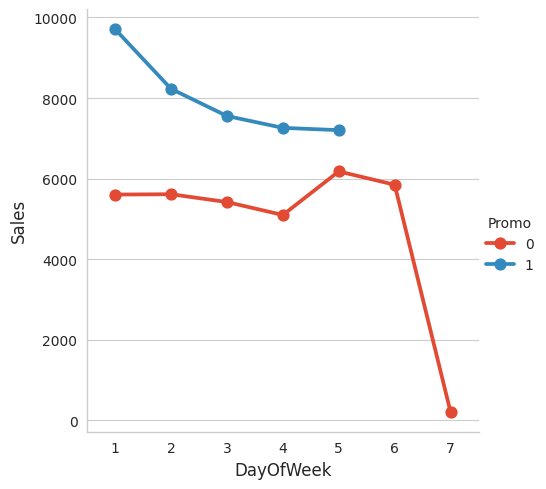

In [53]:
sns.catplot(data = df, x = "DayOfWeek", y = "Sales", kind='point',hue = "Promo")

In [54]:
print("""So, no promotion in the weekend. However, the sales are very high, if the stores have promotion.
The Sales are going crazy on Sunday. No wonder.""")
print("There are", df[(df.Open == 1) & (df.DayOfWeek == 7)].Store.unique().shape[0], "stores opend on sundays")

So, no promotion in the weekend. However, the sales are very high, if the stores have promotion. 
The Sales are going crazy on Sunday. No wonder.
There are 33 stores opend on sundays


**Let's see the trends on a yearly basis.**

<Figure size 1500x700 with 0 Axes>

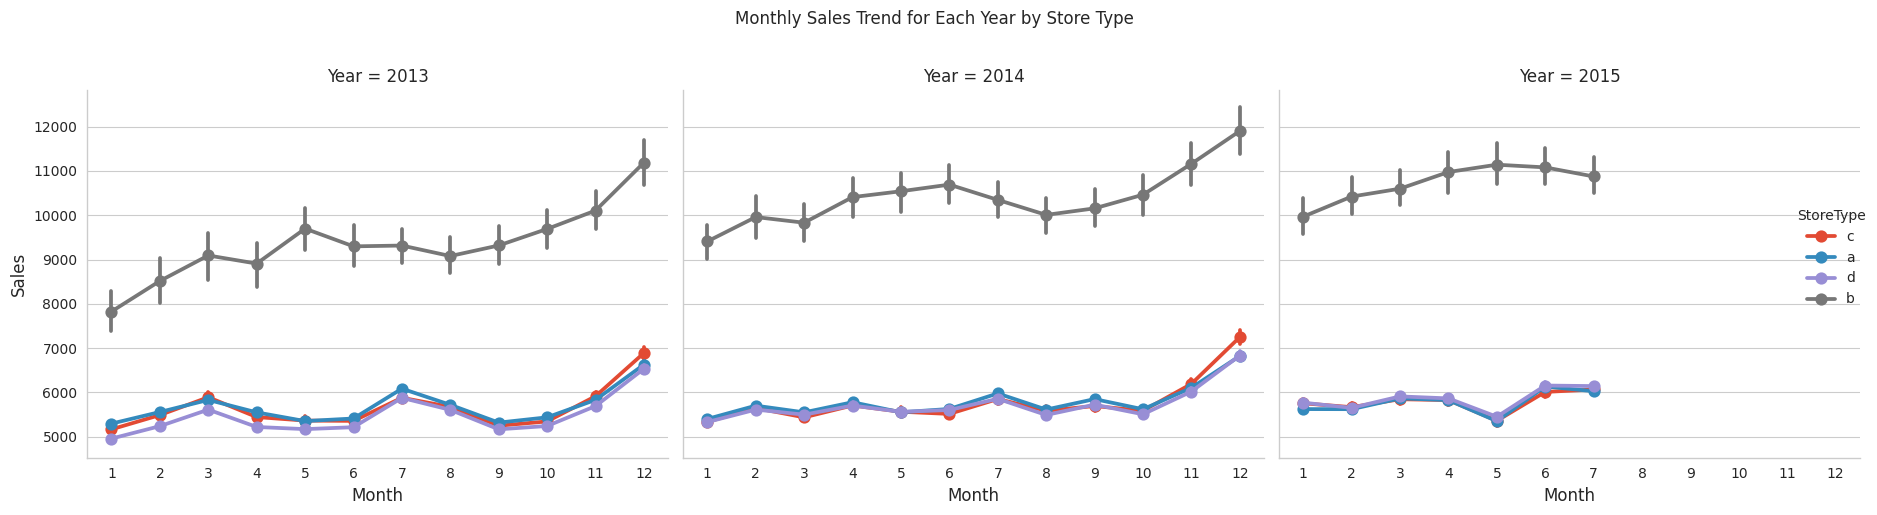

In [55]:
plt.figure(figsize=(15, 7))
sns.catplot(data = df, x = "Month", y = "Sales", col = "Year", hue = "StoreType", kind="point", aspect=1.2, height=5)
plt.suptitle('Monthly Sales Trend for Each Year by Store Type', y=1.02) # Add a suptitle for the entire figure
plt.tight_layout()
plt.show()

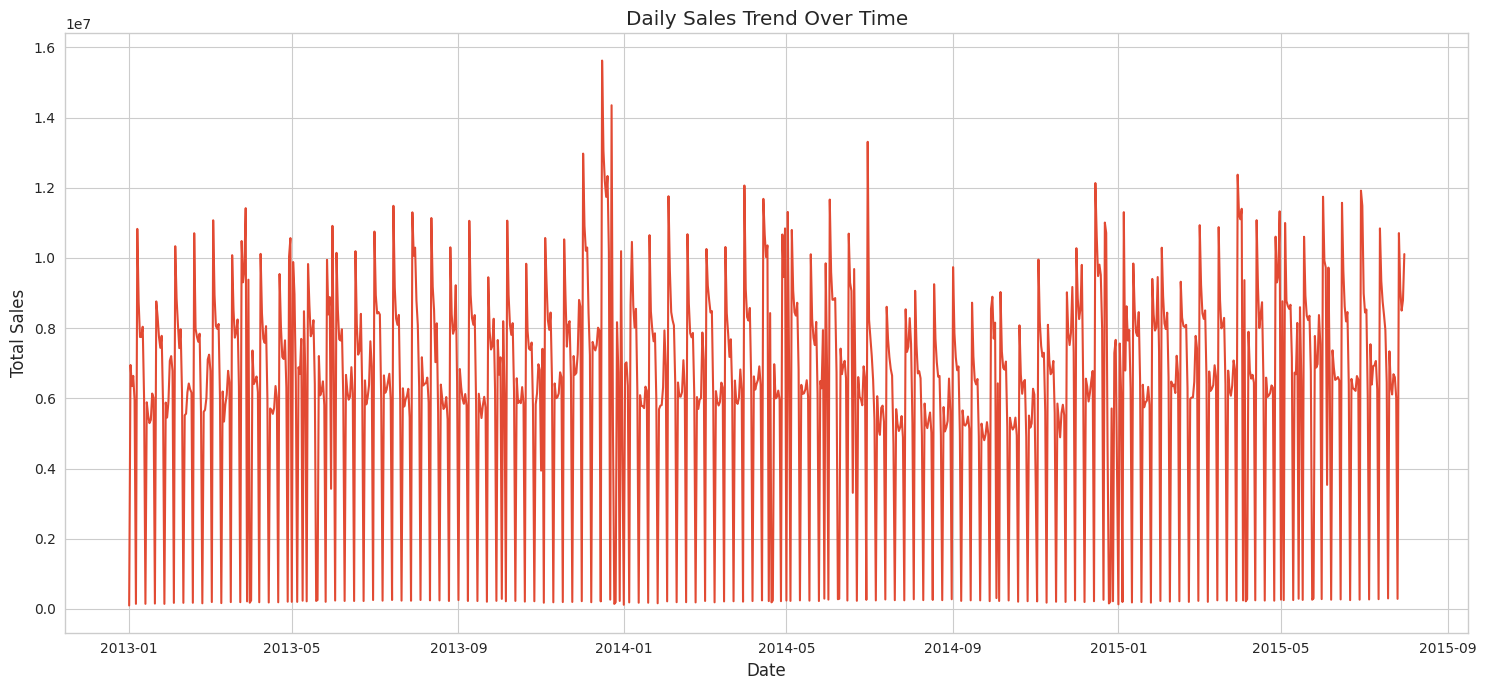

In [56]:
daily_sales_trend = df.groupby('Date')['Sales'].sum().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Sales', data=daily_sales_trend)
plt.title('Daily Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

**What about the Competition Distance. What kind of inpact does this have on the sales.**

In [57]:
df.CompetitionDistance.describe()
# The obsverations are continous numbers, so we need to convert them into a categories. Lets a create a new variable.
df["CompetitionDistance_Cat"] = pd.cut(df["CompetitionDistance"], 5)

/tmp/ipython-input-2097891435.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(by = "CompetitionDistance_Cat").Sales.mean().plot(kind = "bar", title = "Average Total Sales by Competition Distance", ax = ax[0])
/tmp/ipython-input-2097891435.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(by = "CompetitionDistance_Cat").Customers.mean().plot(kind = "bar", title = "Average Total Customers by Competition Distance", ax = ax[1])


<Axes: title={'center': 'Average Total Customers by Competition Distance'}, xlabel='CompetitionDistance_Cat'>

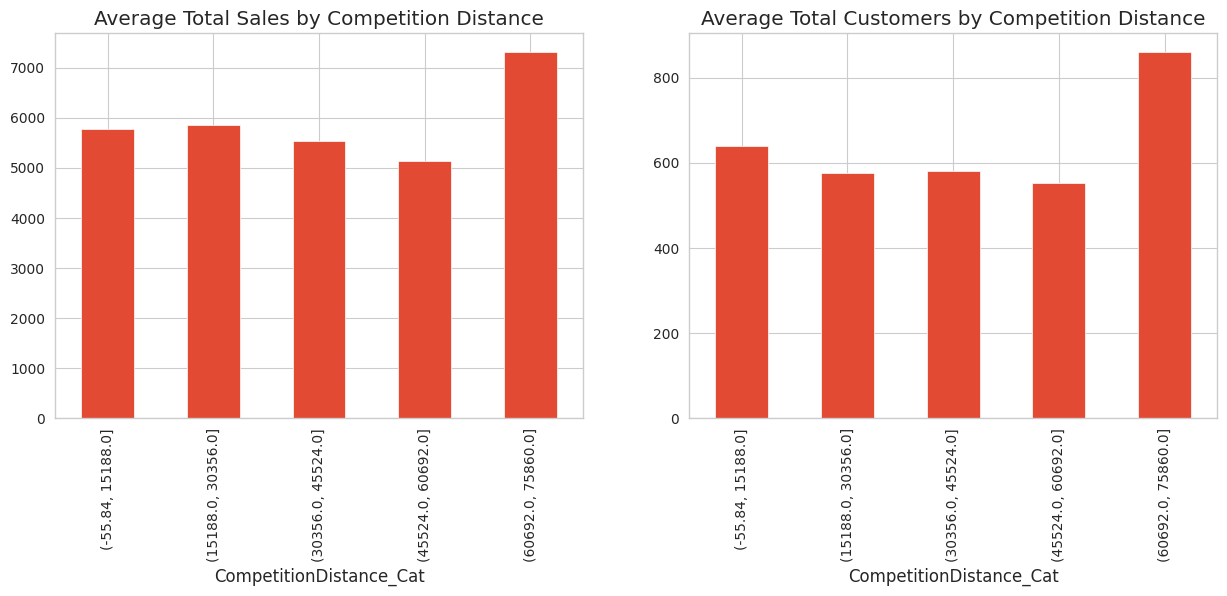

In [58]:
f, ax = plt.subplots(1,2, figsize = (15,5))

df.groupby(by = "CompetitionDistance_Cat").Sales.mean().plot(kind = "bar", title = "Average Total Sales by Competition Distance", ax = ax[0])
df.groupby(by = "CompetitionDistance_Cat").Customers.mean().plot(kind = "bar", title = "Average Total Customers by Competition Distance", ax = ax[1])

# It is pretty clear. If the competions is very far away, the stores are performing better (sales and customers)

In [59]:
# df.drop(['Avg_Customer_Sales','CompetitionDistance_Cat'],axis=1,inplace=True)

## **Conclusion of the analysis:**

**Sales are highly correlated to number of Customers.**

**The most selling and crowded store type is A.**

**StoreType B has the lowest Average Sales per Customer. So i think customers visit this type only for small things.**

**StoreTybe D had the highest buyer cart.**

**Promo runs only in weekdays.**

**For all stores, Promotion leads to increase in Sales and Customers both.**

**More stores are opened during School holidays than State holidays.**

**The stores which are opened during School Holiday have more sales than normal days.**

**Sales are increased during Chirstmas week, this might be due to the fact that people buy more beauty products during a Christmas celebration.**

**Promo2 doesnt seems to be correlated to any significant change in the sales amount.**

**Absence of values in features CompetitionOpenSinceYear/Month doesn’t indicate the absence of competition as CompetitionDistance values are not null where the other two values are null.**

## **Drop Subsets Of Data Where Might Cause Bias**

In [60]:
# where stores are closed, they won't generate sales, so we will remove that part of the dataset
df = df[df.Open != 0]

In [61]:
# Open isn't a variable anymore, so we'll drop it too
df = df.drop('Open', axis=1)

In [62]:
# Check if there's any opened store with zero sales
df[df.Sales == 0]['Store'].sum()

np.int64(31460)

In [63]:
# see the percentage of open stored with zero sales
df[df.Sales == 0]['Sales'].sum()/df.Sales.sum()

np.float64(0.0)

In [64]:
# remove this part of data to avoid bias
df = df[df.Sales != 0]

In [65]:
df_new=df.copy()

In [66]:
df_new

,Store,DayOfWeek,Date,Sales,Customers,Promo,SchoolHoliday,Year,Month,Day,...,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Avg_Customer_Sales,CompetitionDistance_Cat
0,1,5,2015-07-31,5263,555,1,1,2015,7,31,...,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,9.482883,"(-55.84, 15188.0]"
1,2,5,2015-07-31,6064,625,1,1,2015,7,31,...,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",9.702400,"(-55.84, 15188.0]"
2,3,5,2015-07-31,8314,821,1,1,2015,7,31,...,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",10.126675,"(-55.84, 15188.0]"
3,4,5,2015-07-31,13995,1498,1,1,2015,7,31,...,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,9.342457,"(-55.84, 15188.0]"
4,5,5,2015-07-31,4822,559,1,1,2015,7,31,...,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,8.626118,"(15188.0, 30356.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,0,1,2013,1,1,...,a,150.0,9.0,2006.0,0,NaN,NaN,NaN,5.962898,"(-55.84, 15188.0]"
1016827,733,2,2013-01-01,10765,2377,0,1,2013,1,1,...,b,860.0,10.0,1999.0,0,NaN,NaN,NaN,4.528818,"(-55.84, 15188.0]"
1016863,769,2,2013-01-01,5035,1248,0,1,2013,1,1,...,b,840.0,NaN,NaN,1,48.0,2012.0,"Jan,Apr,Jul,Oct",4.034455,"(-55.84, 15188.0]"
1017042,948,2,2013-01-01,4491,1039,0,1,2013,1,1,...,b,1430.0,NaN,NaN,0,NaN,NaN,NaN,4.322425,"(-55.84, 15188.0]"


In [67]:
df_new

,Store,DayOfWeek,Date,Sales,Customers,Promo,SchoolHoliday,Year,Month,Day,...,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Avg_Customer_Sales,CompetitionDistance_Cat
0,1,5,2015-07-31,5263,555,1,1,2015,7,31,...,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,9.482883,"(-55.84, 15188.0]"
1,2,5,2015-07-31,6064,625,1,1,2015,7,31,...,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",9.702400,"(-55.84, 15188.0]"
2,3,5,2015-07-31,8314,821,1,1,2015,7,31,...,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",10.126675,"(-55.84, 15188.0]"
3,4,5,2015-07-31,13995,1498,1,1,2015,7,31,...,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,9.342457,"(-55.84, 15188.0]"
4,5,5,2015-07-31,4822,559,1,1,2015,7,31,...,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,8.626118,"(15188.0, 30356.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,0,1,2013,1,1,...,a,150.0,9.0,2006.0,0,NaN,NaN,NaN,5.962898,"(-55.84, 15188.0]"
1016827,733,2,2013-01-01,10765,2377,0,1,2013,1,1,...,b,860.0,10.0,1999.0,0,NaN,NaN,NaN,4.528818,"(-55.84, 15188.0]"
1016863,769,2,2013-01-01,5035,1248,0,1,2013,1,1,...,b,840.0,NaN,NaN,1,48.0,2012.0,"Jan,Apr,Jul,Oct",4.034455,"(-55.84, 15188.0]"
1017042,948,2,2013-01-01,4491,1039,0,1,2013,1,1,...,b,1430.0,NaN,NaN,0,NaN,NaN,NaN,4.322425,"(-55.84, 15188.0]"


In [68]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Select categorical columns
cat_cols = df_new.select_dtypes(include=['object', 'category']).columns

print("Categorical columns:", cat_cols)  # sanity check

# Initialize encoder (IMPORTANT: sparse_output=False for dense output or use .toarray() later)
# Using sparse_output=False directly in OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Encode
encoded = encoder.fit_transform(df_new[cat_cols])

# Create encoded dataframe
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=df_new.index
)

# Drop original categorical columns
df_new_final = df_new.drop(columns=cat_cols, errors='ignore') # Use errors='ignore' if columns might already be dropped

# Concatenate
df_new = pd.concat([df_new_final, encoded_df], axis=1)

Categorical columns: Index(['StoreType', 'Assortment', 'PromoInterval', 'CompetitionDistance_Cat'], dtype='object')


In [69]:
df_new.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,SchoolHoliday,Year,Month,Day,...,Assortment_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec",PromoInterval_nan,"CompetitionDistance_Cat_(-55.84, 15188.0]","CompetitionDistance_Cat_(15188.0, 30356.0]","CompetitionDistance_Cat_(30356.0, 45524.0]","CompetitionDistance_Cat_(45524.0, 60692.0]","CompetitionDistance_Cat_(60692.0, 75860.0]"
0,1,5,2015-07-31,5263,555,1,1,2015,7,31,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,2,5,2015-07-31,6064,625,1,1,2015,7,31,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3,5,2015-07-31,8314,821,1,1,2015,7,31,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,4,5,2015-07-31,13995,1498,1,1,2015,7,31,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,5,5,2015-07-31,4822,559,1,1,2015,7,31,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


**From plot it can be sen that most of the sales have been on 1st and last day of week**

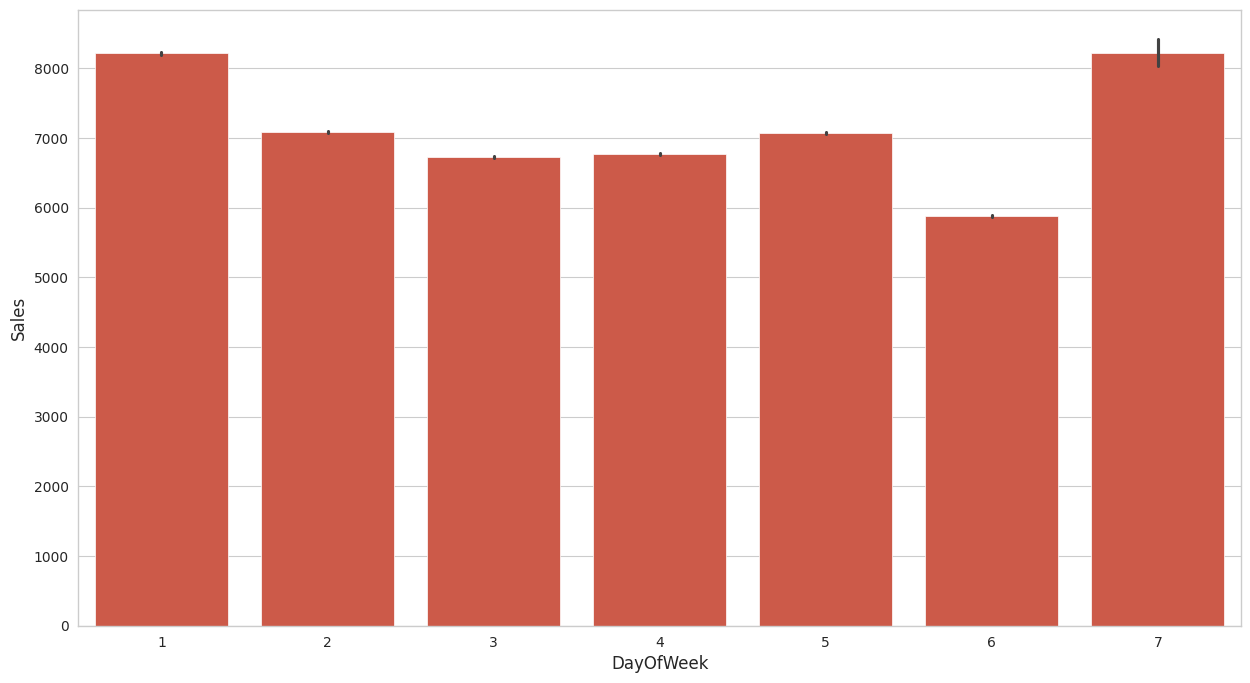

In [70]:
#plot for sales in terms of days ofthe week
plt.figure(figsize=(15,8))
sns.barplot(x='DayOfWeek', y='Sales' ,data=df_new);

## **Setting Features and Target Variables**

In [71]:
df_new.dropna(inplace= True)

In [72]:
df_new.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Promo',
       'SchoolHoliday', 'Year', 'Month', 'Day', 'WeekOfYear',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'Avg_Customer_Sales', 'StoreType_a', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b',
       'Assortment_c', 'PromoInterval_Feb,May,Aug,Nov',
       'PromoInterval_Jan,Apr,Jul,Oct', 'PromoInterval_Mar,Jun,Sept,Dec',
       'PromoInterval_nan', 'CompetitionDistance_Cat_(-55.84, 15188.0]',
       'CompetitionDistance_Cat_(15188.0, 30356.0]',
       'CompetitionDistance_Cat_(30356.0, 45524.0]',
       'CompetitionDistance_Cat_(45524.0, 60692.0]',
       'CompetitionDistance_Cat_(60692.0, 75860.0]'],
      dtype='object')

In [73]:
df_new.dtypes

,0
Store,int64
DayOfWeek,int64
Date,datetime64[ns]
Sales,int64
Customers,int64
Promo,int64
SchoolHoliday,int64
Year,int64
Month,int64
Day,int64


In [74]:
train3  = pd.read_csv('train.csv', low_memory= False)

In [75]:
train2 = pd.merge(train3, store_df, on='Store')

In [76]:
train2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1017209 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [77]:


def features_create(data):


    mappings = {'0':0, 'a':1, 'b':2, 'c':3, 'd':4}
    data.StoreType.replace(mappings, inplace=True)
    data.Assortment.replace(mappings, inplace=True)
    data.StateHoliday.replace(mappings, inplace=True)

    data['Date'] = pd.to_datetime(data.Date)
    data['Year'] = data.Date.dt.year
    data['Month'] = data.Date.dt.month
    data['Day'] = data.Date.dt.day
    data['DayOfWeek'] = data.Date.dt.dayofweek
    data['WeekOfYear'] = data.Date.dt.year



    data['CompetitionOpen'] = 12 * (data.Year - data.CompetitionOpenSinceYear) +         (data.Month - data.CompetitionOpenSinceMonth)
    data['PromoOpen'] = 12 * (data.Year - data.Promo2SinceYear) +         (data.WeekOfYear - data.Promo2SinceWeek) / 4.0
    data['CompetitionOpen'] = data.CompetitionOpen.apply(lambda x: x if x > 0 else 0)
    data['PromoOpen'] = data.PromoOpen.apply(lambda x: x if x > 0 else 0)



    month2str = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',              7:'Jul', 8:'Aug', 9:'Sept', 10:'Oct', 11:'Nov', 12:'Dec'}
    data['monthStr'] = data.Month.map(month2str)
    data.loc[data.PromoInterval == 0, 'PromoInterval'] = ''
    data['IsPromoMonth'] = 0


    return data


In [78]:
features_create(train2)

/tmp/ipython-input-2160905554.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.StoreType.replace(mappings, inplace=True)
/tmp/ipython-input-2160905554.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.StoreType.replace(mappings, inplace=True)
/tmp/ipython-input-2160905554.py:6: Future

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear,CompetitionOpen,PromoOpen,monthStr,IsPromoMonth
0,1,4,2015-07-31,5263,555,1,1,0,1,3,...,NaN,NaN,2015,7,31,2015,82.0,0.00,Jul,0
1,2,4,2015-07-31,6064,625,1,1,0,1,1,...,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,2015,92.0,560.50,Jul,0
2,3,4,2015-07-31,8314,821,1,1,0,1,1,...,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,2015,103.0,548.25,Jul,0
3,4,4,2015-07-31,13995,1498,1,1,0,1,3,...,NaN,NaN,2015,7,31,2015,70.0,0.00,Jul,0
4,5,4,2015-07-31,4822,559,1,1,0,1,1,...,NaN,NaN,2015,7,31,2015,3.0,0.00,Jul,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,1,2013-01-01,0,0,0,0,1,1,1,...,2013.0,"Jan,Apr,Jul,Oct",2013,1,1,2013,0.0,495.50,Jan,0
1017205,1112,1,2013-01-01,0,0,0,0,1,1,3,...,NaN,NaN,2013,1,1,2013,81.0,0.00,Jan,0
1017206,1113,1,2013-01-01,0,0,0,0,1,1,1,...,NaN,NaN,2013,1,1,2013,0.0,0.00,Jan,0
1017207,1114,1,2013-01-01,0,0,0,0,1,1,1,...,NaN,NaN,2013,1,1,2013,0.0,0.00,Jan,0


In [79]:
train2 = train2.set_index('Date')




## SARIMAX

In [80]:

train2.head()


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear,CompetitionOpen,PromoOpen,monthStr,IsPromoMonth
Date,,,,,,,,,,,,,,,,,,,,,
2015-07-31,1,4,5263,555,1,1,0,1,3,1,...,NaN,NaN,2015,7,31,2015,82.0,0.00,Jul,0
2015-07-31,2,4,6064,625,1,1,0,1,1,1,...,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,2015,92.0,560.50,Jul,0
2015-07-31,3,4,8314,821,1,1,0,1,1,1,...,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,2015,103.0,548.25,Jul,0
2015-07-31,4,4,13995,1498,1,1,0,1,3,3,...,NaN,NaN,2015,7,31,2015,70.0,0.00,Jul,0
2015-07-31,5,4,4822,559,1,1,0,1,1,1,...,NaN,NaN,2015,7,31,2015,3.0,0.00,Jul,0


For Time Series Anlaysis , we consider one store from each store type a , b , c ,d

In [81]:
train2['Sales'] = train2['Sales'] * 1.0

In [82]:

sales_a = train2[train2.Store == 2]['Sales']
sales_b = train2[train2.Store == 85]['Sales'].sort_index(ascending = True) # solve the reverse order
sales_c = train2[train2.Store == 1]['Sales']
sales_d = train2[train2.Store == 13]['Sales']

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

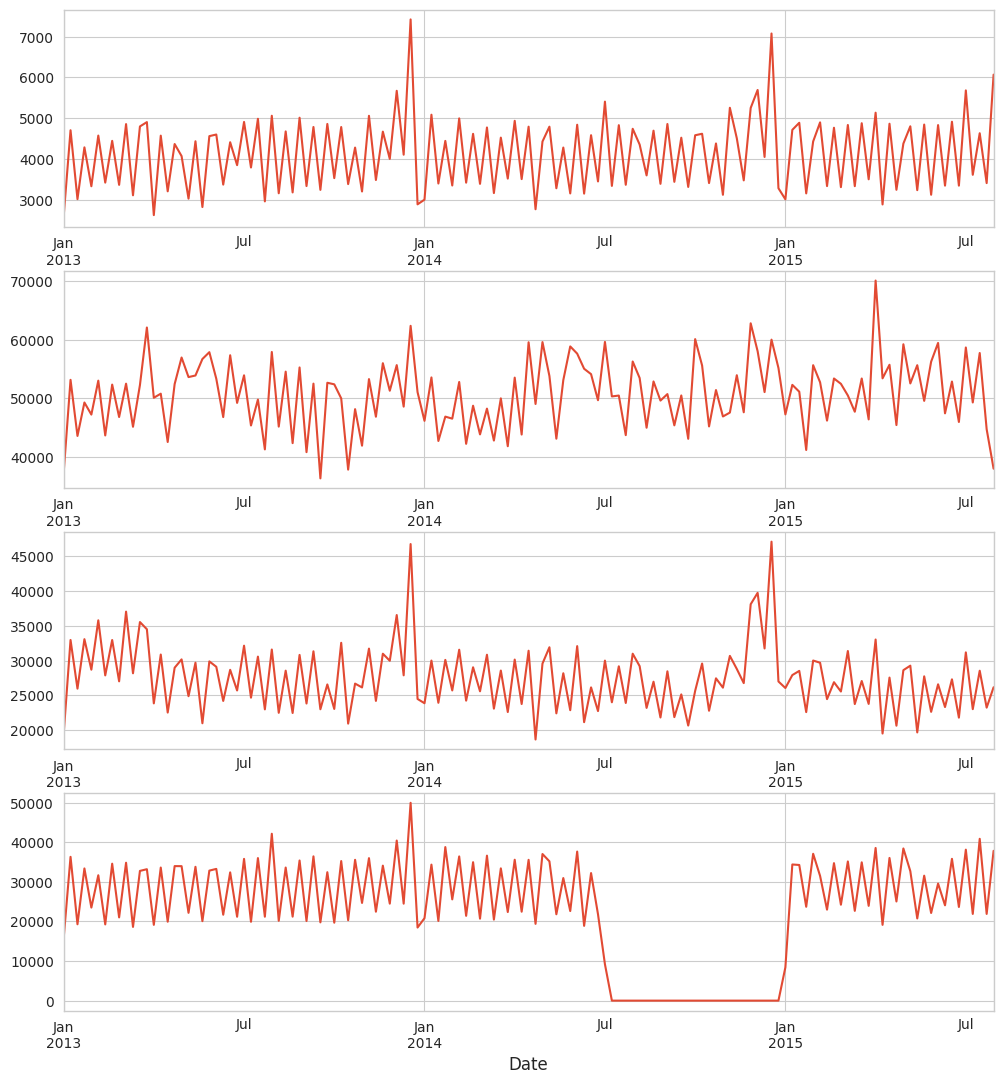

In [83]:
#Lets plot the sales of each store on Weekly basis
f, (ax1, ax2, ax3, ax4) = plt.subplots(4, figsize = (12, 13))

# store types
sales_a.resample('W').mean().plot(ax = ax1)
sales_b.resample('W').sum().plot(ax = ax2)
sales_c.resample('W').sum().plot(ax = ax3)
sales_d.resample('W').sum().plot(ax = ax4)

plt.savefig("weekly_sales.png")

from google.colab import files
files.download("weekly_sales.png")

In [84]:

rollmean = sales_a.rolling(window=7).mean()
rollstd = sales_a.rolling(window=7).std()

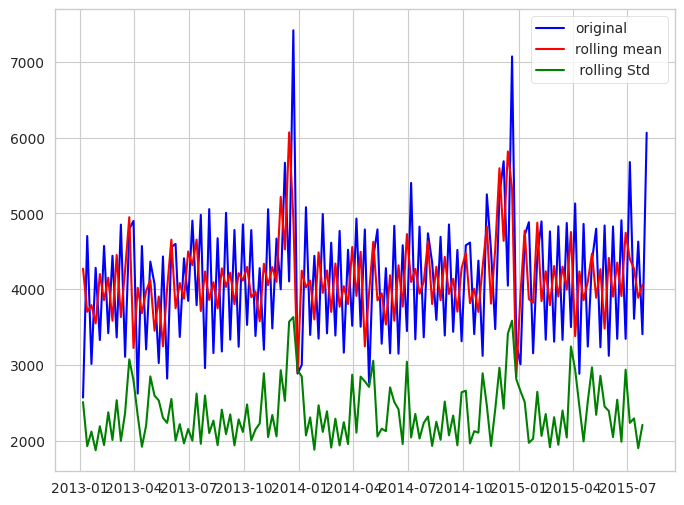

In [85]:
orig = plt.plot(sales_a.resample('W').mean(),color='blue',label='original')
roll_mean = plt.plot(rollmean.resample('W').mean(),color='red',label='rolling mean')
orig_std = plt.plot(rollstd.resample('W').mean(),color='green',label=' rolling Std')
plt.legend(loc='best')
plt.show(block=False)

Dicky - Fuller test It is the test which essentially provides the details whether the Null hypothesis(Data is not stationary) should be rejected against alternate hypothesis(Data is stationary) It gives the Statistical measures explaining the ADF-Statistics value which should be less than the critical values we accept / reject the null hypothesis based on the p-value p-value < 0.5 indicates that the null hypothesis should be rejected

Thus from our data it is clear that our data is stationary and doesnot change heavily with time.

The Akaike information criterion (AIC) : It is an estimator of the relative quality of statistical models for a given set of data. Given a collection of models for the data, AIC estimates the quality of each model, relative to each of the other models. Thus, AIC provides a means for model selection.

ADF statistics should be less than the critical interval

In [86]:

from statsmodels.tsa.stattools import adfuller
def stationary_check(sales):
  result = adfuller(sales,autolag='AIC')
  print('ADF Statistic: %f' % result[0])
  print('p-value: %f' % result[1])
  print('Critical Values:')
  for key, value in result[4].items():
	   print(key, value)


In [87]:

stationary_check(sales_a)
stationary_check(sales_b)
stationary_check(sales_c)
stationary_check(sales_d)

ADF Statistic: -6.218237
p-value: 0.000000
Critical Values:
1% -3.4374778690219956
5% -2.864686684217556
10% -2.5684454926748583
ADF Statistic: -5.660918
p-value: 0.000001
Critical Values:
1% -3.437485646962348
5% -2.8646901138095378
10% -2.568447319459459
ADF Statistic: -4.374784
p-value: 0.000329
Critical Values:
1% -3.4374778690219956
5% -2.864686684217556
10% -2.5684454926748583
ADF Statistic: -6.237461
p-value: 0.000000
Critical Values:
1% -3.4392539652094154
5% -2.86546960465041
10% -2.5688625527782327


If the test statistic is less than the critical value, we fail to reject the null hypothesis and we say series is stationary

If Time is Series is not Stationary

Below are the steps that can be performed to make a timeseries stationary

Take the log of data(Sales) Calcualte Moving Avergae = Log of data - Rolling value of log data Calculate weighted avergate = log of data - exponential of log data

Decomposition Plots :

Now lets plot the decomposition which shows the trend, Seasonality and residuals in sales for each store Type

In [88]:
def plot_timeseries(sales,StoreType):

    fig, axes = plt.subplots(3, 1, sharex=True, sharey=False)
    fig.set_figheight(10)
    fig.set_figwidth(15)

    decomposition= seasonal_decompose(sales, model = 'additive',freq=360)

    estimated_trend = decomposition.trend
    estimated_seasonal = decomposition.seasonal
    estimated_residual = decomposition.resid



    axes[0].plot(estimated_trend, label='Trend')
    axes[0].legend(loc='upper left');

    axes[1].plot(estimated_seasonal, 'g', label='Seasonality')
    axes[1].legend(loc='upper left');

    axes[2].plot(estimated_residual, 'r', label='Residuals')
    axes[2].legend(loc='upper left')

    plt.title('Decomposition for StoreType')

In [89]:

def plot_timeseries(sales,StoreType):

    fig, axes = plt.subplots(3, 1, sharex=True, sharey=False)
    fig.set_figheight(10)
    fig.set_figwidth(15)

    decomposition= seasonal_decompose(sales, model = 'additive', period=360)

    estimated_trend = decomposition.trend
    estimated_seasonal = decomposition.seasonal
    estimated_residual = decomposition.resid



    axes[0].plot(estimated_trend, label='Trend')
    axes[0].legend(loc='upper left');

    axes[1].plot(estimated_seasonal, 'g', label='Seasonality')
    axes[1].legend(loc='upper left');

    axes[2].plot(estimated_residual, 'r', label='Residuals')
    axes[2].legend(loc='upper left')

    plt.title('Decomposition for StoreType')
    plt.savefig("decomposition.png")






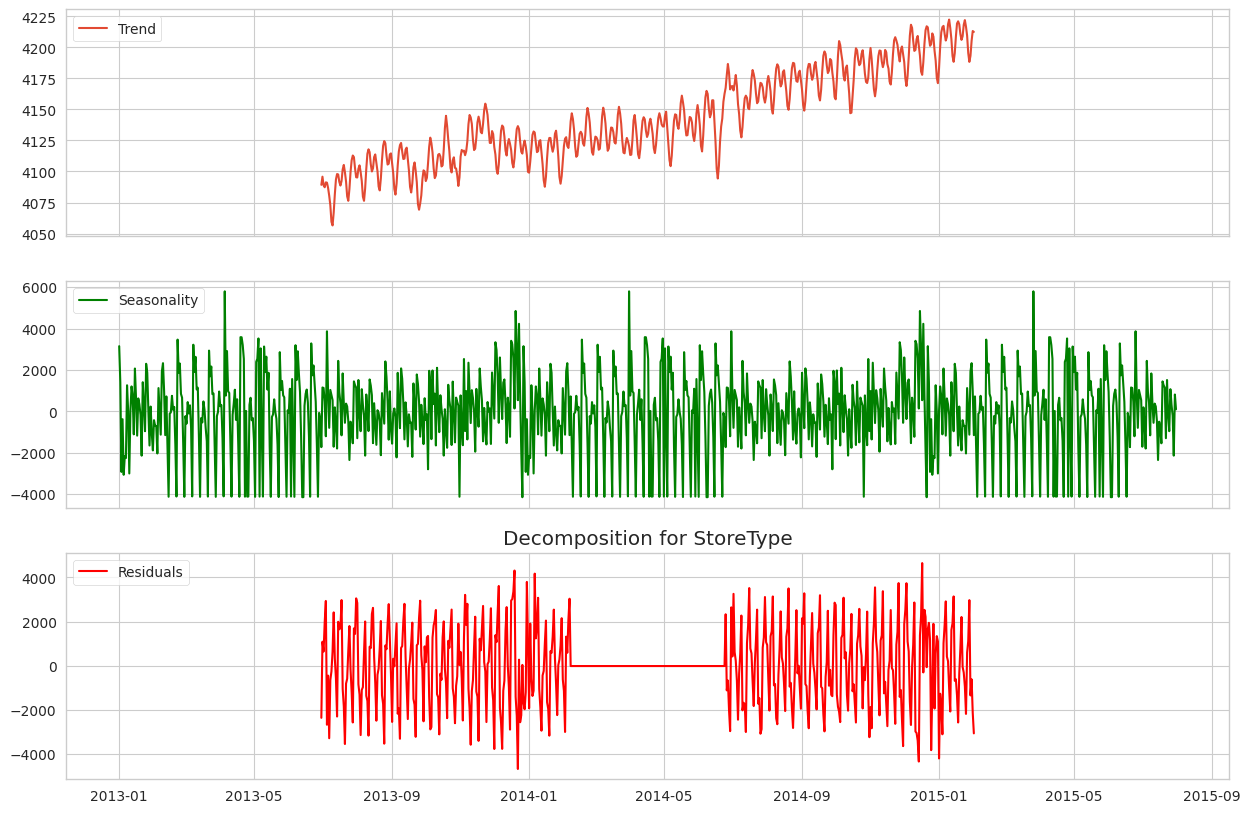

In [90]:
plot_timeseries(sales_a,'a')

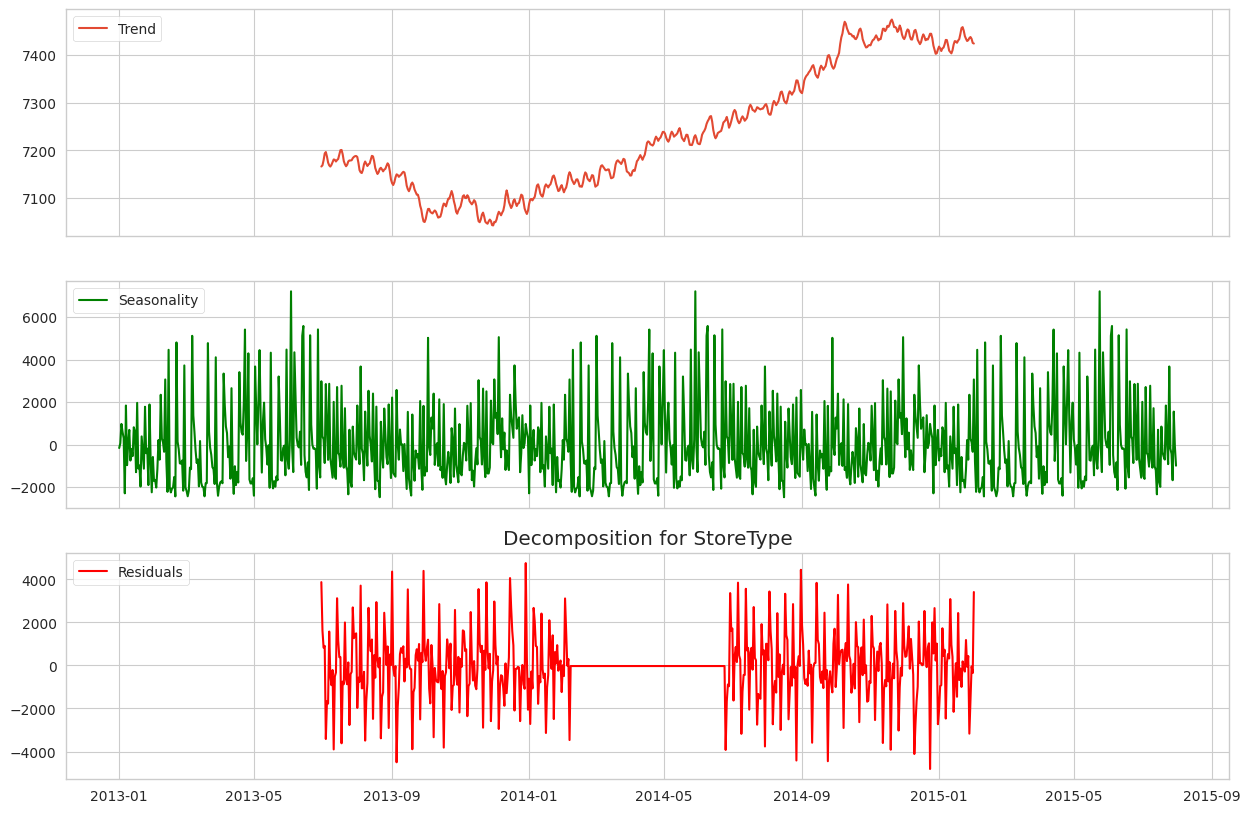

In [91]:
plot_timeseries(sales_b,'b')

Autocorrelation : Autocorrelation, also known as serial correlation or cross-autocorrelation, is the cross-correlation of a signal with itself at different points in time. It is the correlation between values of the process at different times. Informally, it is the similarity between observations as a function of the time lag between them. It is a mathematical tool for finding repeating patterns, such as the presence of a periodic signal obscured by noise.

The next step in ourtime series analysis is to review Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots.

Autocorrelation Function (ACF) : ACF is a measure of the correlation between the timeseries with a lagged version of itself. For instance at lag 5, ACF would compare series at time instant ‘t1’…’tn’ with series at instant ‘t1-5’…’tn-5’ (t1-5 and tn being end points).

Partial Autocorrelation Function (PACF) : PACF measures the correlation between the timeseries with a lagged version of itself but after eliminating the variations explained by the intervening comparisons. Eg. at lag 5, it will check the correlation but remove the effects already explained by lags 1 to 4.

In [92]:

def auto_corr(sales):
    lag_acf = acf(sales,nlags=30)
    lag_pacf = pacf(sales,nlags=20,method='ols')


    plt.subplot(121)
    plt.plot(lag_acf)
    plt.axhline(y=0,linestyle='--',color ='red')
    plt.axhline(y=1.96/np.sqrt(len(sales_a)),linestyle='--',color ='red')
    plt.axhline(y=-1.96/np.sqrt(len(sales_a)),linestyle='--',color ='red')
    plt.title('ACF')


    plt.subplot(122)
    plt.plot(lag_pacf)
    plt.axhline(y=0,linestyle='--',color ='red')
    plt.axhline(y=1.96/np.sqrt(len(sales_a)),linestyle='--',color ='red')
    plt.axhline(y=-1.96/np.sqrt(len(sales_a)),linestyle='--',color ='red')
    plt.title('PACF')

In [93]:
sales_a

,Sales
Date,
2015-07-31,6064.0
2015-07-30,5567.0
2015-07-29,6402.0
2015-07-28,5671.0
2015-07-27,6627.0
...,...
2013-01-05,2342.0
2013-01-04,4484.0
2013-01-03,4159.0


<Figure size 1200x600 with 0 Axes>

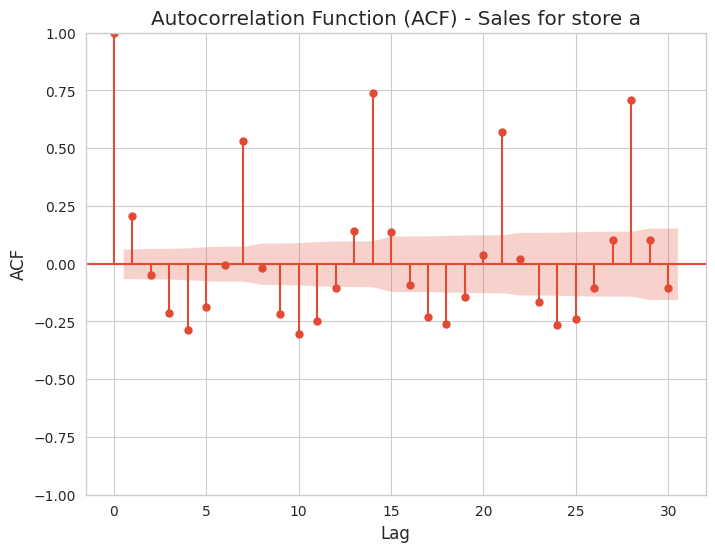

In [94]:
# Plot ACF for Sales
plt.figure(figsize=(12, 6))
plot_acf(sales_a, lags=30, title='Autocorrelation Function (ACF) - Sales for store a')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.show()

<Figure size 1200x600 with 0 Axes>

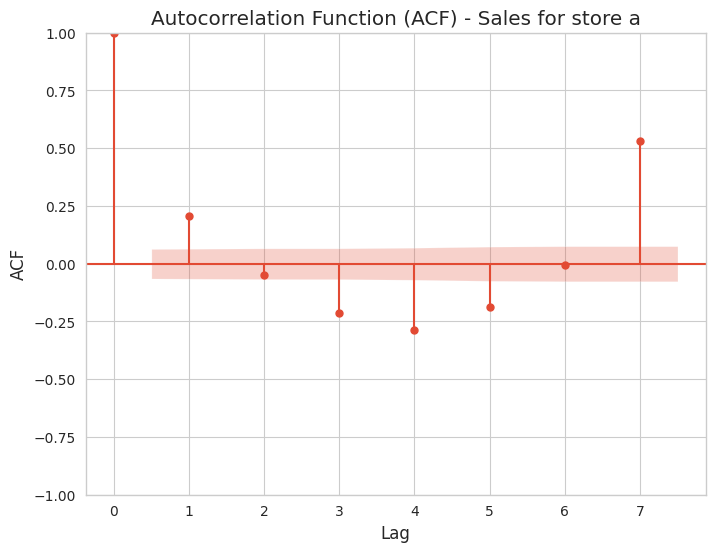

In [95]:
# Plot ACF for Sales
plt.figure(figsize=(12, 6))
plot_acf(sales_a, lags=7, title='Autocorrelation Function (ACF) - Sales for store a')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.show()

<Figure size 1200x600 with 0 Axes>

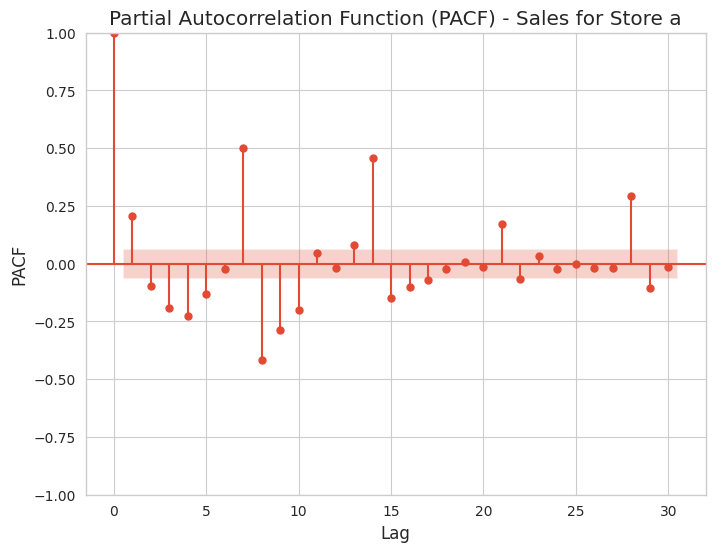

In [96]:
# Plot PACF for Sales
plt.figure(figsize=(12, 6))
plot_pacf(sales_a, lags=30, title='Partial Autocorrelation Function (PACF) - Sales for Store a')
plt.xlabel('Lag')
plt.ylabel('PACF')
plt.show()

<Figure size 1200x600 with 0 Axes>

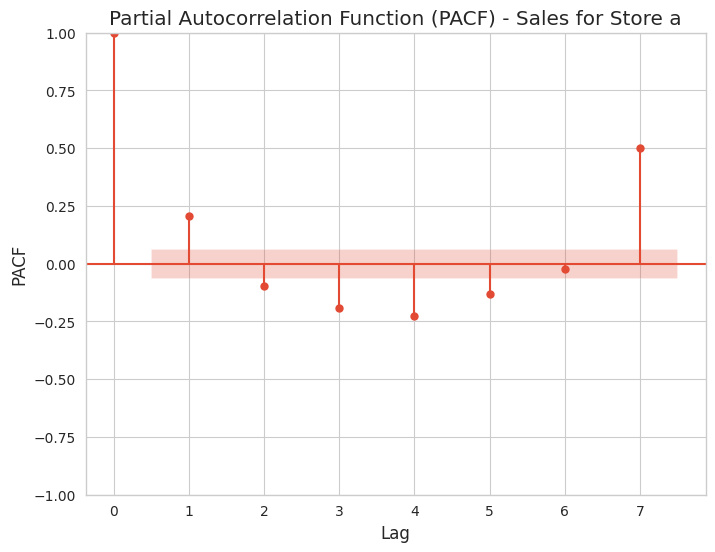

In [97]:
# Plot PACF for Sales
plt.figure(figsize=(12, 6))
plot_pacf(sales_a, lags=7, title='Partial Autocorrelation Function (PACF) - Sales for Store a')
plt.xlabel('Lag')
plt.ylabel('PACF')
plt.show()

<Figure size 1200x600 with 0 Axes>

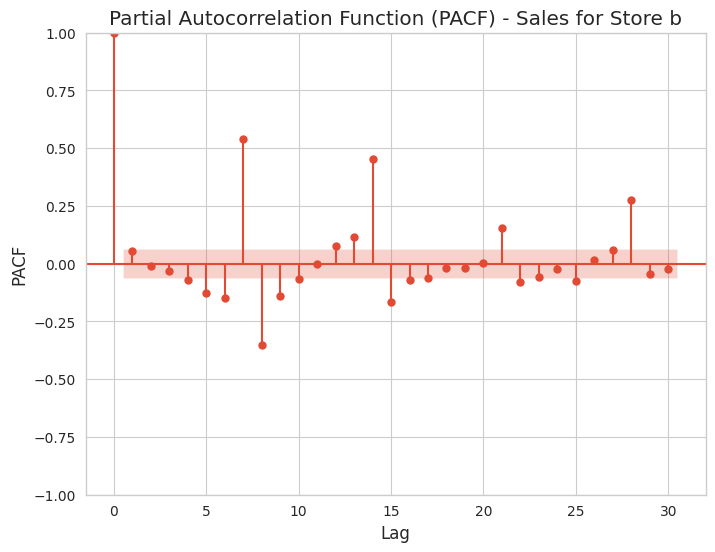

In [98]:
# Plot PACF for Sales
plt.figure(figsize=(12, 6))
plot_pacf(sales_b, lags=30, title='Partial Autocorrelation Function (PACF) - Sales for Store b')
plt.xlabel('Lag')
plt.ylabel('PACF')
plt.show()

Since th above ACF and PACF plots shows that the values of Q and P should be 2,3 respectively , Lets do a grid search and test the AIC for each model to select the best p , d ,q parametes. The model having lowest AIC determines an accurate performance. The AIC measures how well a model fits the data while taking into account the overall complexity of the model. A model that fits the data very well while using lots of features will be assigned a larger AIC score than a model that uses fewer features to achieve the same goodness-of-fit. Therefore, we are interested in finding the model that yields the lowest AIC value.

*Arima Model *(Autoregressive Indegrated Moving Average) determines the forecast of Sales data

We have to decide the p,d,q for the arima model to fit the data to get the proper prediction:

p(Auto Regression) as the name suggests , it determines the effect of previous sales on the current sale.It takes into consideration the effect of previous sale. It is represented by : Y_{t} = c + ph1(1)Y_{t-1} + phi_{2}Y_{t-2} + ...... + phi_{p}Y_{t-p} + e_{t}

p =1 ,determines that the effect of previous month has been taken. ph1 determines the variable (Sales) for which we are lagging sales_value by 1. Auto Regression model of order 1 i.e. p=1 or ARIMA(1,0,0) is represented by the following regression equation Y_{t} = c + ph1(1)Y_{t-1}

d = determines the diffrence taken between original series and the lagged series to achieve the stationarity. d = 0 , determins that the series was already stationary. d = 1 , determines that the series was subtracted from its lagged series to attain stationary Auto Regression model of order 1 i.e. d=1 or ARIMA(0,1,0) is represented by the following regression equation y(t_new) = y(t) - y(t-1)

q(Moving Average) = extract the influence of the previous period’s error terms on the current period’s error MA model of order 1 i.e. q=1 or ARIMA(0,0,1) is represented by the following regression equation Y_{t} = c + e_t + theta_{1}e_{t-1}

Δyt=c+ϕ1Δyt−1+θ1ϵt−1+ϵt

In [99]:

# Define the p, d and q parameters to take any value between 0 and 2
p = d = q = range(0, 2)

# Generate all different combinations of p, q and q triplets
pdq = list(itertools.product(p, d, q))

# Generate all different combinations of seasonal p, q and q triplets
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

print('Examples of parameter combinations for Seasonal ARIMA...')
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[1]))
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[2]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[3]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[4]))

Examples of parameter combinations for Seasonal ARIMA...
SARIMAX: (0, 0, 1) x (0, 0, 1, 12)
SARIMAX: (0, 0, 1) x (0, 1, 0, 12)
SARIMAX: (0, 1, 0) x (0, 1, 1, 12)
SARIMAX: (0, 1, 0) x (1, 0, 0, 12)


In [100]:

def sample(sales):
  return(sales.resample('MS').mean())

In [101]:

y_sale_a = sample(sales_a)
y_sale_b = sample(sales_b)
y_sale_c = sample(sales_c)
y_sale_d = sample(sales_d)

In [102]:
def model(i,sale):
  ex = train2.loc[train2['Store'] == i,['Customers','Promo']]
#   ex = train2.loc[train2['Store'] == i]
#   ex.drop(['Open','PromoInterval','monthStr','Customers'],axis=1,inplace =True)
  y_sales = sale.resample('MS').mean()
  y_ex = ex.resample('MS').mean()
  exog = sm.add_constant(y_ex)
  exog.tail()
  return y_sales , exog

In [103]:

y_sale_model_a , exog_a = model(2,sales_a)
y_sale_model_b , exog_b = model(85,sales_b)
y_sale_model_c , exog_c = model(1,sales_c)
y_sale_model_d , exog_d = model(13,sales_d)

In [104]:
exog_a

,const,Customers,Promo
Date,,,
2013-01-01,1.0,455.709677,0.322581
2013-02-01,1.0,468.750000,0.357143
2013-03-01,1.0,480.451613,0.483871
2013-04-01,1.0,473.400000,0.400000
2013-05-01,1.0,467.032258,0.419355
2013-06-01,1.0,475.866667,0.333333
2013-07-01,1.0,570.645161,0.419355
2013-08-01,1.0,494.032258,0.387097
2013-09-01,1.0,475.933333,0.333333


In [105]:

exog_a = exog_a.dropna()
exog_a.isna().sum()

exog_b = exog_b.dropna()
exog_b.isna().sum()

exog_c = exog_c.dropna()
exog_c.isna().sum()

exog_d = exog_d.dropna()
exog_d.isna().sum()

,0
const,0
Customers,0
Promo,0


In [117]:
def arima(y_sale,exog,or1,sord):
    mod = sm.tsa.statespace.SARIMAX(y_sale,
                                    exog,
                                    order=or1,
                                    seasonal_order=sord,
                                    enforce_stationarity=False,
                                    enforce_invertibility=False)



    results = mod.fit(disp=0)
    ## -----------------------predictions-------------------
    pred = results.get_prediction(start=pd.to_datetime('2015-01-01'), end=pd.to_datetime('2015-07-01'), dynamic=False)
    # forecasted_sarimax = results.get_forecast(steps=6,  exog=exog)
    # forecast_mean = forecasted_sarimax.predicted_mean
    # print(forecast_mean)
    pred_ci = pred.conf_int()

   ##------------------------plot-----------------------------
    ax = y_sale['2013':].plot(label='observed')
    pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7)

    ax.fill_between(pred_ci.index,
                      pred_ci.iloc[:, 1],
                      pred_ci.iloc[:, 1], color='k', alpha=.2)

    ax.set_xlabel('Date')
    ax.set_ylabel('sales')
    plt.legend()

    plt.show()


    y_forecasted = pred.predicted_mean
    y_truth = y_sale['2015-01-01':'2015-07-01']


   ##-------------Compute the mean square error----------------
    mse = ((y_forecasted - y_truth) ** 2).mean()
    rmse = np.sqrt(((y_forecasted - y_truth) ** 2).mean())
    rmspe =  np.sqrt(np.mean((y_forecasted/y_truth) ** 2))
    return results , mse,rmse,rmspe

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


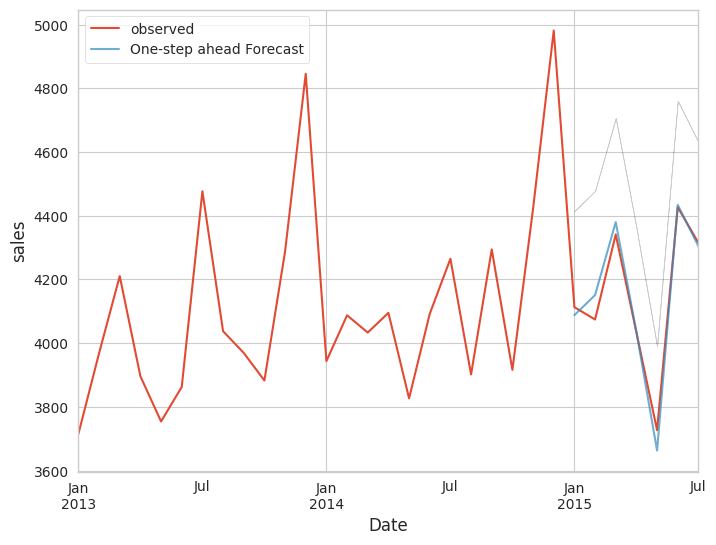

                                      SARIMAX Results                                      
Dep. Variable:                               Sales   No. Observations:                   31
Model:             SARIMAX(5, 1, 3)x(1, 0, [], 12)   Log Likelihood                 -79.215
Date:                             Mon, 15 Dec 2025   AIC                            184.430
Time:                                     18:40:10   BIC                            191.775
Sample:                                 01-01-2013   HQIC                           182.921
                                      - 07-01-2015                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0019    445.908   -4.2e-06      1.000    -873.966     873.963
Customers      8.9653     4

In [118]:
or_a = (5,1,3)
sord_a=(1, 0, 0, 12)
result_a,mse_a,rmse_a,rmspe_a= arima(y_sale_model_a,exog_a,or_a,sord_a)
print(result_a.summary())
print('The Mean Squared Error of our forecasts is {}'.format(round(mse_a, 2)))
print('The Root Squared Error of our forecasts is {}'.format(round(rmse_a, 2)))
print('The Root Squared Per Error of our forecasts is {}'.format(round(rmspe_a, 2)))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


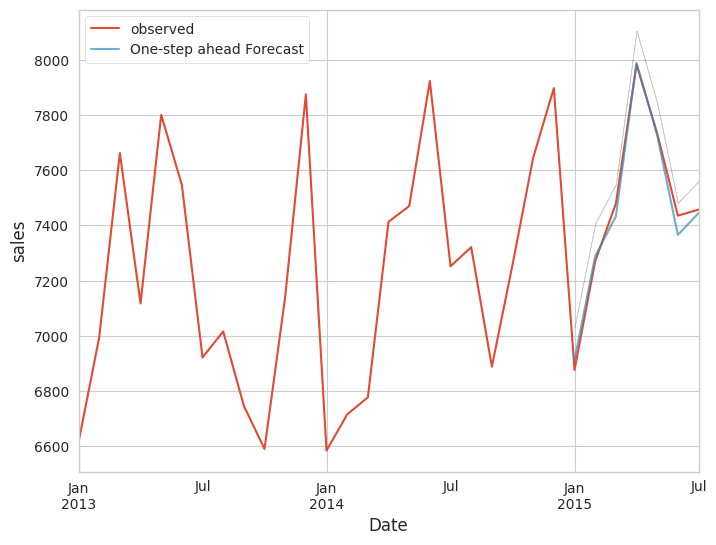

                                      SARIMAX Results                                      
Dep. Variable:                               Sales   No. Observations:                   31
Model:             SARIMAX(3, 2, 3)x(1, 0, [], 12)   Log Likelihood                 -79.186
Date:                             Mon, 15 Dec 2025   AIC                            180.373
Time:                                     18:40:15   BIC                            187.402
Sample:                                 01-01-2013   HQIC                           179.722
                                      - 07-01-2015                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0201   1.89e+04   1.06e-06      1.000   -3.71e+04    3.71e+04
Customers      7.0233      

In [119]:
or_b = (3,2,3)
sord_b=(1, 0, 0, 12)
result_b,mse_b,rmse_b,rmspe_b= arima(y_sale_model_b,exog_b,or_b,sord_b)
print(result_b.summary())
print('The Mean Squared Error of our forecasts is {}'.format(round(mse_b, 2)))
print('The Root Squared Error of our forecasts is {}'.format(round(rmse_b, 2)))
print('The Root Squared Per Error of our forecasts is {}'.format(round(rmspe_b, 2)))

## Light GBM Model with only date parts features without advanced feature engineering

In [120]:
features1 = ['Store','DayOfWeek','Promo','Year','Month','Day']
X = df_new[features1]
y = df_new['Sales']

# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31
}

model = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(stopping_rounds=10)]
)

# Evaluate
y_pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f'Validation RMSE: {rmse}')
# # predictions are on log scale (Sales_log); use evaluate_metrics with from_log_scale=True
# evaluate_metrics(y_val, y_pred, 'LightGBM Baseline', from_log_scale=True)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.051117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 298
[LightGBM] [Info] Number of data points in the train set: 214230, number of used features: 6
[LightGBM] [Info] Start training from score 6544.232059
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[18]	valid_0's rmse: 2513.06
Validation RMSE: 2513.0573649221906


In [121]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) *100


mae = mae(y_val, y_pred)
rmse = rmse(y_val, y_pred)
mape = mape(y_val, y_pred)
wape = wape(y_val, y_pred)
print(f"mae",{mae})
print(f"rmse",{rmse})


print(f"mape",{mape})
print(f"wape",{wape})

mae {np.float64(1883.0890077236213)}
rmse {np.float64(2513.0573649221906)}
mape {np.float64(32.879447742009546)}
wape {np.float64(28.893387802535127)}


## Advanced Feature Engineering

In [122]:
# Advanced Feature Engineering
#Competition Features

#We'll calculate the number of months a competitor has been open.
#This can help the model understand the impact of competition on sales over time.

# Promotion Features

# We'll create features related to the continuous Promo2 promotion. Specifically, we'll calculate:

# Promo2Open: The duration (in months) that Promo2 has been active for a given store.

# Competition Open Since
for df_temp in [df_new]: # Renamed df to df_temp to avoid confusion with the global df variable if it was ever needed unmodified
    df_temp['CompetitionOpenSinceYear'] = df_temp['CompetitionOpenSinceYear'].fillna(0)
    df_temp['CompetitionOpenSinceMonth'] = df_temp['CompetitionOpenSinceMonth'].fillna(0)
    df_temp['Promo2SinceYear'] = df_temp['Promo2SinceYear'].fillna(0)
    df_temp['Promo2SinceWeek'] = df_temp['Promo2SinceWeek'].fillna(0)

    df_temp['CompetitionOpen'] = 12 * (df_temp['Year'] - df_temp['CompetitionOpenSinceYear']) + \
                               (df_temp['Month'] - df_temp['CompetitionOpenSinceMonth'])
    df_temp['CompetitionOpen'] = df_temp['CompetitionOpen'].apply(lambda x: x if x > 0 else 0)

    df_temp['Promo2Open'] = 12 * (df_temp['Year'] - df_temp['Promo2SinceYear']) + \
                          (df_temp['Month'] - (df_temp['Promo2SinceWeek'] // 4))
    df_temp['Promo2Open'] = df_temp['Promo2Open'].apply(lambda x: x if x > 0 else 0)

# Lag Features (Sales)
df_new = df_new.sort_values(['Store','Date'])
train = df_new

# Drop the categorical column 'CompetitionDistance_Cat' before filling NaNs globally
# as it is not part of the 'features' for the model and causes a TypeError when filling with 0.
if 'CompetitionDistance_Cat' in train.columns:
    train = train.drop('CompetitionDistance_Cat', axis=1)
# Also drop Avg_Customer_Sales if it's not intended for the model, as it was previously created
if 'Avg_Customer_Sales' in train.columns:
    train = train.drop('Avg_Customer_Sales', axis=1)

train['Sales_lag1'] = train.groupby('Store')['Sales'].shift(1)
train['Sales_lag7'] = train.groupby('Store')['Sales'].shift(7)

train['Sales_roll7'] = train.groupby('Store')['Sales'].shift(1).rolling(7).mean()
train['Sales_roll30'] = train.groupby('Store')['Sales'].shift(1).rolling(30).mean()

# Fill NA values from lag features and other newly created features
# Now 'CompetitionDistance_Cat' and 'Avg_Customer_Sales' are dropped, fillna(0) should be safe for remaining columns.
train = train.fillna(0)

# Update features
features = ['Store','DayOfWeek','Promo','Year','Month','Day','CompetitionOpen','Promo2Open',
            'Sales_lag1','Sales_lag7','Sales_roll7','Sales_roll30']
X = train[features]

y = train['Sales']

X

,Store,DayOfWeek,Promo,Year,Month,Day,CompetitionOpen,Promo2Open,Sales_lag1,Sales_lag7,Sales_roll7,Sales_roll30
1014981,2,3,0,2013,1,2,62.0,34.0,0.0,0.0,0.000000,0.000000
1013866,2,4,0,2013,1,3,62.0,34.0,4422.0,0.0,0.000000,0.000000
1012751,2,5,0,2013,1,4,62.0,34.0,4159.0,0.0,0.000000,0.000000
1011636,2,6,0,2013,1,5,62.0,34.0,4484.0,0.0,0.000000,0.000000
1009406,2,1,1,2013,1,7,62.0,34.0,2342.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
5570,1111,1,1,2015,7,27,13.0,24.0,2177.0,2622.0,3586.142857,4502.333333
4455,1111,2,1,2015,7,28,13.0,24.0,7742.0,4321.0,4317.571429,4599.933333
3340,1111,3,1,2015,7,29,13.0,24.0,6793.0,4457.0,4670.714286,4681.100000
2225,1111,4,1,2015,7,30,13.0,24.0,4907.0,4021.0,4735.000000,4702.800000


In [123]:
# Re-train with advanced features
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5
}

# FIXED: Use callback API for early stopping
model_adv = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    num_boost_round=200,
    callbacks=[lgb.early_stopping(stopping_rounds=20)]
)

# Evaluate advanced model
y_pred = model_adv.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f'Validation RMSE: {rmse}')



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1646
[LightGBM] [Info] Number of data points in the train set: 214230, number of used features: 12
[LightGBM] [Info] Start training from score 6544.232059
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[170]	valid_0's rmse: 1029.87
Validation RMSE: 1029.866365211789


In [128]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) *100

def mase(actual_values, predicted_values):

    # Actual and predicted values
    actual_values = np.array(y_val)
    predicted_values = np.array(y_pred)

    # Calculate the absolute error for each prediction
    absolute_errors = np.abs(actual_values - predicted_values)

    # Calculate the mean absolute error of the naive forecast
    naive_forecast_errors = np.abs(np.diff(actual_values))
    naive_mae = np.mean(naive_forecast_errors)

    # Calculate MASE
    mase = np.mean(absolute_errors) / naive_mae
    return mase

def sMAPE(actual_values, predicted_values):

  sMAPE = np.mean(2 * np.abs(actual_values - predicted_values) / (np.abs(actual_values) + np.abs(predicted_values))) * 100
  return sMAPE

def bias(actual_values, predicted_values):
    return np.mean(actual_values - predicted_values)

import numpy as np

def rmspe(y_true, y_pred):
    """
    Calculate Root Mean Square Percentage Error (RMSPE).

    Parameters:
        y_true (array-like): Actual values
        y_pred (array-like): Predicted values

    Returns:
        float: RMSPE value
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)

    # Avoid division by zero
    if np.any(y_true == 0):
        raise ValueError("y_true contains zero values, cannot compute percentage error.")

    percentage_errors = (y_true - y_pred) / y_true
    return np.sqrt(np.mean(np.square(percentage_errors))) * 100  # in percentage
import numpy as np

def wape(y_true, y_pred):
    """
    Calculate Weighted Absolute Percentage Error (WAPE).

    Parameters:
        y_true (array-like): Actual values
        y_pred (array-like): Predicted values

    Returns:
        float: WAPE value in percentage
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)

    denominator = np.sum(np.abs(y_true))
    if denominator == 0:
        raise ValueError("Sum of actual values is zero, cannot compute WAPE.")

    return (np.sum(np.abs(y_true - y_pred)) / denominator) * 100
import numpy as np

def wmape(y_true, y_pred):
    """
    Calculate Weighted Mean Absolute Percentage Error (WMAPE).

    Parameters:
        y_true (array-like): Actual values
        y_pred (array-like): Predicted values

    Returns:
        float: WMAPE value in percentage
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)

    denominator = np.sum(np.abs(y_true))
    if denominator == 0:
        raise ValueError("Sum of actual values is zero, cannot compute WMAPE.")

    return (np.sum(np.abs(y_true - y_pred)) / denominator) * 100


mae = mae(y_val, y_pred)
rmse = rmse(y_val, y_pred)
rmspe = rmspe(y_val, y_pred)
mape = mape(y_val, y_pred)
wape = wape(y_val, y_pred)
wmape=wmape(y_val, y_pred)
mase = mase(y_val, y_pred)
sMAPE = sMAPE(y_val, y_pred)
bias=bias(y_val, y_pred)
print(f"mae",{mae})
print(f"rmse",{rmse})
print(f"Mean Absolute Scaled Error (MASE): {mase:.4f}")
print(f"Symmetric Mean Absolute Percentage Error (sMAPE): {sMAPE:.2f}%")

print("rmspe", rmspe)
print(f"mape",{mape})
print(f"wape",{wape})
print(f"wmape", wmape)


print(f"bias",{bias})


mae {np.float64(709.2391722461015)}
rmse {np.float64(1029.866365211789)}
Mean Absolute Scaled Error (MASE): 0.5213
Symmetric Mean Absolute Percentage Error (sMAPE): 11.48%
rmspe 18.913766093501422
mape {np.float64(12.0662473916096)}
wape {np.float64(10.882290940260884)}
wmape 10.882290940260884
bias {np.float64(36.10182357101901)}


The Mean Absolute Scaled Error (MASE) is an error metric used for evaluating the accuracy of time series forecasts. It is designed to address some limitations of traditional error metrics like Mean Absolute Percentage Error (MAPE) and Mean Squared Error (MSE). MASE is scaled, meaning it normalizes the forecast errors by comparing them with a baseline forecast. This baseline forecast is typically a "naive" forecast, where the predicted value for each time point is equal to the value of the previous time point.

Unlike traditional metrics like MAPE, MASE is scale-independent, making it more suitable for comparing forecasts across different datasets or when the time series data has varying scales.

The primary advantage of MASE is that it handles zero and near-zero values in the time series more effectively than other error metrics. MASE also does not suffer from the problem of undefined errors, which is an issue in MAPE when actual values are zero.



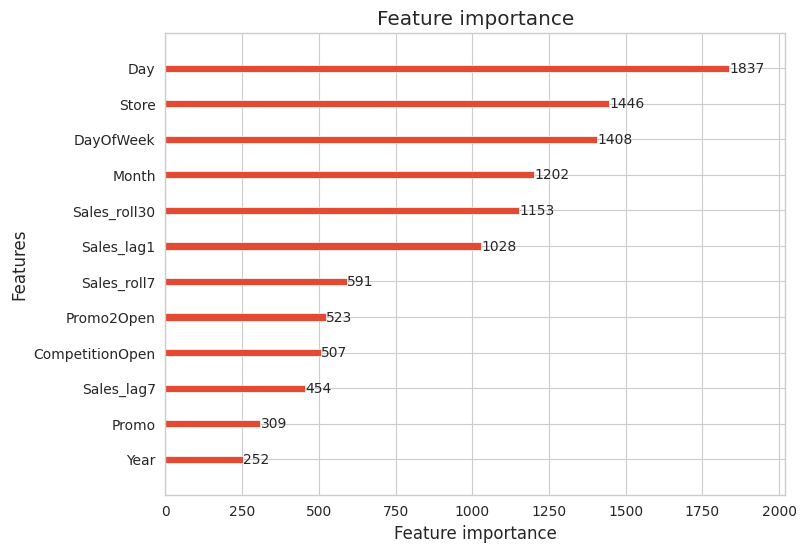

In [111]:
# Feature importance
lgb.plot_importance(model_adv, max_num_features=15)
plt.show()

## Model Explanibility


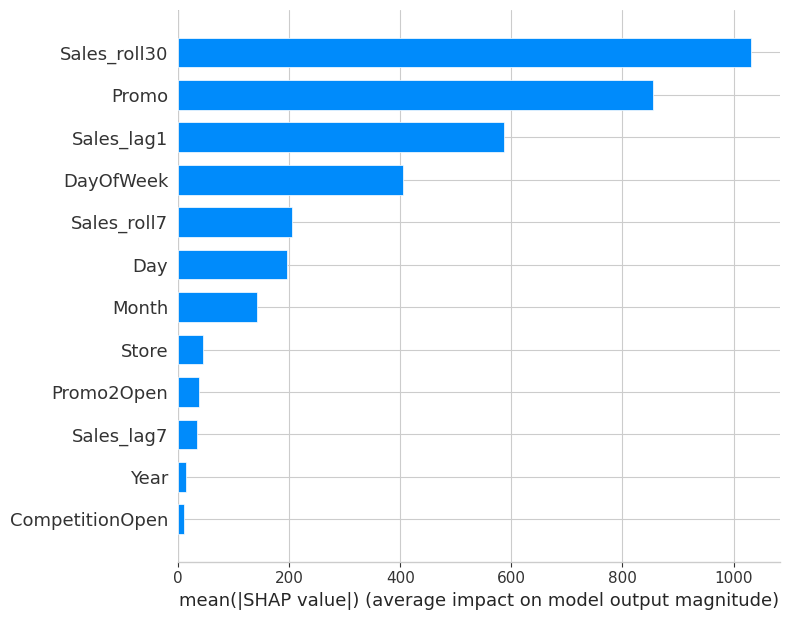

In [129]:
import shap

explainer = shap.TreeExplainer(model_adv)
shap_values = explainer.shap_values(X_val)

shap.summary_plot(shap_values, X_val, plot_type="bar")


## XGBOOST Model

In [130]:

from xgboost import XGBRegressor

In [131]:
# Re-train with advanced features
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

#num_boost_round = 6000
final_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.2,
    max_depth=10,
    subsample=0.9,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

# Evaluate advanced model
y_pred = final_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f'Validation RMSE: {rmse}')



Validation RMSE: 1187.284822609975


In [132]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) *100

def mase(actual_values, predicted_values):

    # Actual and predicted values
    actual_values = np.array(y_val)
    predicted_values = np.array(y_pred)

    # Calculate the absolute error for each prediction
    absolute_errors = np.abs(actual_values - predicted_values)

    # Calculate the mean absolute error of the naive forecast
    naive_forecast_errors = np.abs(np.diff(actual_values))
    naive_mae = np.mean(naive_forecast_errors)

    # Calculate MASE
    mase = np.mean(absolute_errors) / naive_mae
    return mase

def sMAPE(actual_values, predicted_values):

  sMAPE = np.mean(2 * np.abs(actual_values - predicted_values) / (np.abs(actual_values) + np.abs(predicted_values))) * 100
  return sMAPE

def bias(actual_values, predicted_values):
    return np.mean(actual_values - predicted_values)

import numpy as np

def rmspe(y_true, y_pred):
    """
    Calculate Root Mean Square Percentage Error (RMSPE).

    Parameters:
        y_true (array-like): Actual values
        y_pred (array-like): Predicted values

    Returns:
        float: RMSPE value
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)

    # Avoid division by zero
    if np.any(y_true == 0):
        raise ValueError("y_true contains zero values, cannot compute percentage error.")

    percentage_errors = (y_true - y_pred) / y_true
    return np.sqrt(np.mean(np.square(percentage_errors))) * 100  # in percentage
import numpy as np

def wape(y_true, y_pred):
    """
    Calculate Weighted Absolute Percentage Error (WAPE).

    Parameters:
        y_true (array-like): Actual values
        y_pred (array-like): Predicted values

    Returns:
        float: WAPE value in percentage
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)

    denominator = np.sum(np.abs(y_true))
    if denominator == 0:
        raise ValueError("Sum of actual values is zero, cannot compute WAPE.")

    return (np.sum(np.abs(y_true - y_pred)) / denominator) * 100
import numpy as np

def wmape(y_true, y_pred):
    """
    Calculate Weighted Mean Absolute Percentage Error (WMAPE).

    Parameters:
        y_true (array-like): Actual values
        y_pred (array-like): Predicted values

    Returns:
        float: WMAPE value in percentage
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)

    denominator = np.sum(np.abs(y_true))
    if denominator == 0:
        raise ValueError("Sum of actual values is zero, cannot compute WMAPE.")

    return (np.sum(np.abs(y_true - y_pred)) / denominator) * 100


mae = mae(y_val, y_pred)
rmse = rmse(y_val, y_pred)
rmspe = rmspe(y_val, y_pred)
mape = mape(y_val, y_pred)
wape = wape(y_val, y_pred)
wmape=wmape(y_val, y_pred)
mase = mase(y_val, y_pred)
sMAPE = sMAPE(y_val, y_pred)
bias=bias(y_val, y_pred)
print(f"mae",{mae})
print(f"rmse",{rmse})
print(f"Mean Absolute Scaled Error (MASE): {mase:.4f}")
print(f"Symmetric Mean Absolute Percentage Error (sMAPE): {sMAPE:.2f}%")

print("rmspe", rmspe)
print(f"mape",{mape})
print(f"wape",{wape})
print(f"wmape", wmape)


print(f"bias",{bias})

mae {np.float64(819.8529516919741)}
rmse {np.float64(1187.2848039232567)}
Mean Absolute Scaled Error (MASE): 0.6026
Symmetric Mean Absolute Percentage Error (sMAPE): 13.08%
rmspe 21.843417223453997
mape {np.float64(13.791111907505154)}
wape {np.float64(12.57950589543562)}
wmape 12.57950589543562
bias {np.float64(135.45950042623184)}


## **Random Forest With Hyper Parameter Tuning**

In [ ]:

rfr=RandomForestRegressor(n_jobs=-1)

params = {
         'n_estimators':[40,50],
         'min_samples_split':[2,3],
 #        'min_samples_leaf':[1,2],
         'max_depth':[None,5,15]
         }

#the dimensionality is high, the number of combinations we have to search is enormous, using RandomizedSearchCV is a better option then GridSearchCV
grid = RandomizedSearchCV(estimator=rfr,param_distributions=params,verbose=True,cv=2)

#choosing 10 K-Folds makes sure i went through all of the data and didn't miss any pattern.
grid.fit(X_train, y_train)
grid.best_params_

Fitting 2 folds for each of 10 candidates, totalling 20 fits




**Here are our best parameters for Random Forest**

**{ n_estimators=80,min_samples_split=2,min_samples_leaf=1,max_depth=None }**

In [ ]:
#%%time
rdf = RandomForestRegressor(n_estimators=10,min_samples_split=2, min_samples_leaf=1,max_depth=None,n_jobs=-1)
rdfreg = rdf.fit(X_train, y_train)

In [ ]:
train_score_5=rdfreg.score(X_train, y_train)
test_score_5=rdfreg.score(X_val, y_val)

print("Regresion Model Score" , ":" , train_score_5 , "," ,
      "Test Score" ,":" , test_score_5)

y_predicted_2 = rdfreg.predict(X_train)
y_test_predicted_2 = rdfreg.predict(X_val)

# Re-define rmse and mape functions to ensure they are callable
def rmse_func(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
def mape_func(y_true, y_pred):
    # Avoid division by zero: filter out true values that are zero or very close to zero
    non_zero_indices = y_true != 0
    if not np.any(non_zero_indices):
        return np.nan
    return np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices])) * 100

print("Training RMSE", ":", rmse_func(y_train, y_predicted_2),
      "Testing RMSE", ":", rmse_func(y_val, y_test_predicted_2))
print("Training MAPE", ":", mape_func(y_train, y_predicted_2),
      "Testing MAPE", ":", mape_func(y_val, y_test_predicted_2))

In [ ]:
y_test_predicted_2

In [ ]:
#storing 100 observations for analysis
rf_prd = y_test_predicted_2[:100]
rf_real = y_val[:100]
dataset_rf = pd.DataFrame({'Real':rf_real,'PredictedRF':rf_prd})

In [ ]:
#storing absolute diffrences between actual sales price and predicted
dataset_rf['diff']=(dataset_rf['Real']-dataset_rf['PredictedRF']).abs()

In [ ]:
 # taking 4 sample
dataset_rf.sample(4)

In [ ]:
#Statistical description of our predictions and actual values
dataset_rf.describe()

In [ ]:
#plotting the actual,predicted & difference of SALES
dataset_rf.plot.hist(subplots=True, legend=False);

In [ ]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) *100

def mase(actual_values, predicted_values):

    # Actual and predicted values
    actual_values = np.array(y_val)
    predicted_values = np.array(y_pred)

    # Calculate the absolute error for each prediction
    absolute_errors = np.abs(actual_values - predicted_values)

    # Calculate the mean absolute error of the naive forecast
    naive_forecast_errors = np.abs(np.diff(actual_values))
    naive_mae = np.mean(naive_forecast_errors)

    # Calculate MASE
    mase = np.mean(absolute_errors) / naive_mae
    return mase

def sMAPE(actual_values, predicted_values):

  sMAPE = np.mean(2 * np.abs(actual_values - predicted_values) / (np.abs(actual_values) + np.abs(predicted_values))) * 100
  return sMAPE

def bias(actual_values, predicted_values):
    return np.mean(actual_values - predicted_values)

import numpy as np

def rmspe(y_true, y_pred):
    """
    Calculate Root Mean Square Percentage Error (RMSPE).

    Parameters:
        y_true (array-like): Actual values
        y_pred (array-like): Predicted values

    Returns:
        float: RMSPE value
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)

    # Avoid division by zero
    if np.any(y_true == 0):
        raise ValueError("y_true contains zero values, cannot compute percentage error.")

    percentage_errors = (y_true - y_pred) / y_true
    return np.sqrt(np.mean(np.square(percentage_errors))) * 100  # in percentage
import numpy as np

def wape(y_true, y_pred):
    """
    Calculate Weighted Absolute Percentage Error (WAPE).

    Parameters:
        y_true (array-like): Actual values
        y_pred (array-like): Predicted values

    Returns:
        float: WAPE value in percentage
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)

    denominator = np.sum(np.abs(y_true))
    if denominator == 0:
        raise ValueError("Sum of actual values is zero, cannot compute WAPE.")

    return (np.sum(np.abs(y_true - y_pred)) / denominator) * 100
import numpy as np

def wmape(y_true, y_pred):
    """
    Calculate Weighted Mean Absolute Percentage Error (WMAPE).

    Parameters:
        y_true (array-like): Actual values
        y_pred (array-like): Predicted values

    Returns:
        float: WMAPE value in percentage
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)

    denominator = np.sum(np.abs(y_true))
    if denominator == 0:
        raise ValueError("Sum of actual values is zero, cannot compute WMAPE.")

    return (np.sum(np.abs(y_true - y_pred)) / denominator) * 100


mae = mae(y_val, y_pred)
rmse = rmse(y_val, y_pred)
rmspe = rmspe(y_val, y_pred)
mape = mape(y_val, y_pred)
wape = wape(y_val, y_pred)
wmape=wmape(y_val, y_pred)
mase = mase(y_val, y_pred)
sMAPE = sMAPE(y_val, y_pred)
bias=bias(y_val, y_pred)
print(f"mae",{mae})
print(f"rmse",{rmse})
print(f"Mean Absolute Scaled Error (MASE): {mase:.4f}")
print(f"Symmetric Mean Absolute Percentage Error (sMAPE): {sMAPE:.2f}%")

print("rmspe", rmspe)
print(f"mape",{mape})
print(f"wape",{wape})
print(f"wmape", wmape)


print(f"bias",{bias})

**As we can see that Actual, Prediction values are approximately closed to each other and there is no such significant variation in our plots.**

In [ ]:
#visualising our predictions
sns.lmplot(x='Real', y='PredictedRF', data=dataset_rf, line_kws={'color': 'red'}, height=6,aspect=1);

## **Feature Importance On Random Forest Regressor**

As we can see that Random Forest has the highest test score

In [ ]:
def plot_feature_importance(importance,names,model_type):

  #Create arrays from feature importance and feature names
  feature_importance = np.array(importance)
  feature_names = np.array(names)

  #Create a DataFrame using a Dictionary
  data={'feature_names':feature_names,'feature_importance':feature_importance}
  fi_df = pd.DataFrame(data)

  #Sort the DataFrame in order decreasing feature importance
  fi_df.sort_values(by=['feature_importance'], ascending=False,inplace=True)

  #Define size of bar plot
  plt.figure(figsize=(10,8))
  #Plot Searborn bar chart
  sns.barplot(x=fi_df['feature_importance'], y=fi_df['feature_names'])
  #Add chart labels
  plt.title(model_type + ' FEATURE IMPORTANCE')
  plt.xlabel('FEATURE IMPORTANCE')
  plt.ylabel('FEATURE NAMES')

In [ ]:
plot_feature_importance(rdfreg.feature_importances_,columns[:],'RANDOM FOREST')

**Customers, CompetitionDistance, StoreType_d, Promo these four are most important features in our sales prediction.**

### Explanation of Evaluation Metrics

#### 1. Root Mean Square Error (RMSE)
*   **Formula:** $$\sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
*   **Significance:** RMSE measures the average magnitude of the errors. It is the square root of the average of squared differences between prediction and actual observation. Since the errors are squared before they are averaged, RMSE gives a relatively high weight to large errors. This means it is most useful when large errors are particularly undesirable. In sales prediction, a lower RMSE indicates that the model's predictions are closer to the actual sales values on average, and it's sensitive to large deviations which can be important for inventory or budgeting.

#### 2. Mean Squared Error (MSE)
*   **Formula:** $$\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
*   **Significance:** MSE is the average of the squares of the errors. It penalizes larger errors more heavily than smaller errors. It provides a good measure of how close a regression line is to a set of points. In sales, a lower MSE means the model's predictions are accurate, with large errors being heavily penalized. It's often used when we want to strongly penalize large deviations.

#### 3. Mean Absolute Error (MAE)
*   **Formula:** $$\frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
*   **Significance:** MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average of the absolute differences between prediction and actual observation. MAE is more robust to outliers than MSE or RMSE because it doesn't square the errors. For sales prediction, MAE tells us the typical error size in sales units, making it easily interpretable as the average absolute deviation from actual sales.

#### 4. Mean Absolute Percentage Error (MAPE)
*   **Formula:** $$\frac{1}{n} \sum_{i=1}^{n} |\frac{y_i - \hat{y}_i}{y_i}| \times 100\%$$ (for $y_i \neq 0$)
*   **Significance:** MAPE expresses the error as a percentage of the actual value. This makes it useful for comparing accuracy across different scales. However, it can be problematic with actual values close to zero, leading to inflated or undefined errors. In sales forecasting, MAPE is highly intuitive as it provides the average percentage error, which is often easier for business stakeholders to understand than absolute error values. A MAPE of 12.03% means on average, our predictions are off by about 12.03% from the actual sales.

#### 5. Root Mean Square Percentage Error (RMSPE)
*   **Formula:** $$\sqrt{\frac{1}{n} \sum_{i=1}^{n} (\frac{y_i - \hat{y}_i}{y_i})^2}$$ (for $y_i \neq 0$)
*   **Significance:** Similar to RMSE, RMSPE gives higher weight to larger percentage errors, and it's a scale-independent measure. It addresses the issue of comparing errors across different scales better than RMSE alone, while still being sensitive to larger relative errors. In sales, RMSPE is valuable for understanding the relative error impact, especially if sales volumes vary significantly between stores or days.

#### 6. Weighted Mean Absolute Percentage Error (WMAPE)
*   **Formula:** $$\frac{\sum_{i=1}^{n} |y_i - \hat{y}_i|}{\sum_{i=1}^{n} |y_i|}$$
*   **Significance:** WMAPE is a variant of MAPE that avoids division by zero and gives more weight to higher-volume sales. It essentially sums the absolute errors and divides by the sum of actual values, providing a percentage error relative to total sales. This is particularly useful in sales forecasting where the accuracy of predictions for high-volume items or periods is often more critical. A WMAPE of 0.11 (or 11%) means that the total absolute error is 11% of the total actual sales, giving a robust overall error metric.

## Prophet

In [ ]:
# =============================
# Prophet Benchmark (Store 1 Example, Fixed)
# =============================
from prophet import Prophet
rossman_df=pd.read_csv("train.csv")
store=pd.read_csv("store.csv")
train = rossman_df.merge(store, on='Store', how='left')


# Store 1 daily sales
store1 = train[train['Store'] == 1][['Date', 'Sales']].copy()
store1 = store1.rename(columns={'Date': 'ds', 'Sales': 'y'})

# Fit Prophet model
prophet_model = Prophet(changepoint_prior_scale=0.05,yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_model.fit(store1)

# Validation start date from train (based on split point)
val_start_date = train['Date'].iloc[int(len(train) * 0.8)]  # since you did 80/20 split

# Forecast length = number of days after val_start_date
val_len_store1 = (store1['ds'] >= val_start_date).sum()

future = prophet_model.make_future_dataframe(periods=val_len_store1, freq='D')
forecast = prophet_model.predict(future)

# Extract actual vs predicted
val_dates = store1[store1['ds'] >= val_start_date]['ds'].reset_index(drop=True)
val_sales = store1[store1['ds'] >= val_start_date]['y'].reset_index(drop=True)
pred_sales = forecast[['ds', 'yhat']].tail(len(val_dates))['yhat'].values



# Plot results
plt.figure(figsize=(12,5))
plt.plot(val_dates, val_sales, label='Actual')
plt.plot(val_dates, pred_sales, label='Prophet Forecast')
plt.legend()
plt.title('Prophet vs Actual Sales - Store 1 Validation')
#plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [ ]:
# =============================
# LSTM Forecasting (Store 1 Example)
# =============================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Focus on one store (Store 1)
store1 = train[train['Store'] == 1][['Date','Sales']].copy()
store1 = store1.set_index('Date').asfreq('D').fillna(0)

# Scale data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_sales = scaler.fit_transform(store1[['Sales']])

# Create sequences
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 30
X, y = create_sequences(scaled_sales, seq_length)

# Train/validation split
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

# Build LSTM model
model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')

# Train
history = model_lstm.fit(X_train, y_train, epochs=1, batch_size=32,
                         validation_data=(X_val, y_val), verbose=1)

# Predict
preds = model_lstm.predict(X_val)
preds_rescaled = scaler.inverse_transform(preds)
actual = scaler.inverse_transform(y_val.reshape(-1,1))

# Evaluate
preds_flat = preds_rescaled.ravel()
actual_flat = actual.ravel()


# Compare
plt.figure(figsize=(12,5))
plt.plot(actual_flat, label='Actual')
plt.plot(preds_flat, label='LSTM Forecast')
plt.legend()
plt.title('LSTM Forecast vs Actual (Store 1)')
plt.show()